# Final M5 Store-Department Daily Revenue Forecasting Report

Notebook này phân tích dataset `m5_store_dept_daily_with_weather.csv` và xây dựng model dự báo doanh thu ở cấp:

**store_id × dept_id × date**

Cách trình bày bám theo form của `final_weather_sales_project_report.ipynb`: đi từ hiểu dữ liệu, EDA, kiểm soát leakage, feature engineering, modeling, error analysis và kết luận. Code được giữ đơn giản, dễ đọc, không phụ thuộc `sklearn/lightgbm/xgboost` để notebook chạy ổn trong môi trường hiện tại.


## 1. Mục Tiêu Và Nguyên Tắc

Mục tiêu dự báo:

- Target: `daily_revenue`
- Unit: `store_id × dept_id × date`
- Dataset dùng duy nhất: `data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv`

Nguyên tắc modeling:

- Không dùng biến same-day leakage: `daily_units`, `active_item_count`, `weighted_avg_sell_price`, `has_sales`.
- Dùng calendar, event, SNAP, store/dept metadata và history features được tạo bằng lag/rolling từ quá khứ.
- So sánh 2 hướng model:
  - **Model A: no_weather**
  - **Model B: with_weather**
- Split theo thời gian:
  - Train: 2011-2014
  - Validation: 2015
  - Test: 2016 Jan-May


## 2. Common Imports, Theme Và Helper Functions


In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 14

PROJECT_ROOT = Path.cwd()
DATA_RELATIVE_PATH = Path("data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv")
if not (PROJECT_ROOT / DATA_RELATIVE_PATH).exists():
    if (PROJECT_ROOT.parent / DATA_RELATIVE_PATH).exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH

COLOR_MAIN = "#2563eb"
COLOR_ACCENT = "#f97316"
COLOR_GREEN = "#16a34a"
COLOR_RED = "#dc2626"
COLOR_PURPLE = "#7c3aed"
COLOR_GRAY = "#64748b"
PALETTE_CONTRAST = [COLOR_MAIN, COLOR_ACCENT, COLOR_GREEN, COLOR_PURPLE, COLOR_RED, "#0891b2", "#ca8a04", "#be123c"]


def title(text):
    display(Markdown(f"### {text}"))


def show_df(df, n=10):
    display(df.head(n))


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    abs_error = np.abs(y_true - y_pred)
    sq_error = (y_true - y_pred) ** 2
    ss_res = np.sum(sq_error)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {
        "MAE": abs_error.mean(),
        "RMSE": np.sqrt(sq_error.mean()),
        "WAPE": abs_error.sum() / (np.abs(y_true).sum() + 1e-12),
        "R2": 1 - ss_res / (ss_tot + 1e-12),
        "Bias": (y_pred - y_true).mean(),
    }


def display_metrics_table(rows, sort_by="MAE"):
    out = pd.DataFrame(rows)
    if sort_by in out.columns:
        out = out.sort_values(sort_by)
    display(out.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))
    return out


## 3. Load Dataset


In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"])

# Normalize event columns. Missing event means no event, not data quality problem.
for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
    df[col] = df[col].fillna("No Event").astype(str)

print("Path:", DATA_PATH)
print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())
print("Stores:", df["store_id"].nunique(), sorted(df["store_id"].unique()))
print("States:", df["state_id"].nunique(), sorted(df["state_id"].unique()))
print("Categories:", df["cat_id"].nunique(), sorted(df["cat_id"].unique()))
print("Departments:", df["dept_id"].nunique(), sorted(df["dept_id"].unique()))

show_df(df, 5)


Path: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv
Shape: (135870, 56)
Date range: 2011-01-29 -> 2016-05-22
Stores: 10 ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
States: 3 ['CA', 'TX', 'WI']
Categories: 3 ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Departments: 7 ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


,date,d,wm_yr_wk,store_id,state_id,cat_id,dept_id,daily_revenue,daily_units,item_count,active_item_count,weighted_avg_sell_price,has_sales,weekday,wday,month,year,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month,event_name_1,event_type_1,event_name_2,event_type_2,event_count,snap_CA,snap_TX,snap_WI,snap_active,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_1,681.1800,297,216,70,2.2935,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
1,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_2,"2,236.0100",674,398,154,3.3175,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
2,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_3,"4,323.4600",2268,823,285,1.9063,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
3,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_1,"1,276.8600",528,416,101,2.4183,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
4,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_2,93.0500,28,149,17,3.3232,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive


**Nhận xét ban đầu**

Dataset đang ở đúng mức cần dự báo: `date × store_id × dept_id`. Khác với Maven, dữ liệu M5 này là daily panel đầy đủ, mỗi ngày có đủ 10 store và 7 department. Điều này cho phép tạo lag 1/7/28 và rolling theo ngày một cách tự nhiên.


## 4. Schema, Key Và Leakage


In [3]:
key_cols = ["date", "store_id", "dept_id"]
target_col = "daily_revenue"

leakage_cols = ["daily_units", "active_item_count", "weighted_avg_sell_price", "has_sales"]
metadata_cols = ["store_id", "state_id", "cat_id", "dept_id", "item_count"]
calendar_cols = [
    "d", "wm_yr_wk", "weekday", "wday", "month", "year", "quarter", "week_of_year",
    "day_of_month", "day_of_year", "day_of_week", "day_of_week_num", "is_weekend", "year_month",
]
event_snap_cols = [
    "event_name_1", "event_type_1", "event_name_2", "event_type_2", "event_count",
    "snap_CA", "snap_TX", "snap_WI", "snap_active",
]
weather_cols = [
    "weather_location_id", "location_name", "weather_spatial_level", "weather_code",
    "temperature_max_c", "temperature_min_c", "temperature_mean_c", "apparent_temperature_mean_c",
    "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2", "latitude_requested", "longitude_requested", "latitude_open_meteo",
    "longitude_open_meteo", "elevation_m", "timezone", "utc_offset_seconds", "weather_source",
]

schema_summary = pd.DataFrame({
    "group": ["key", "target", "leakage_same_day", "metadata", "calendar", "event_snap", "weather"],
    "n_cols": [len(key_cols), 1, len(leakage_cols), len(metadata_cols), len(calendar_cols), len(event_snap_cols), len(weather_cols)],
    "columns": [key_cols, [target_col], leakage_cols, metadata_cols, calendar_cols, event_snap_cols, weather_cols],
})
display(schema_summary)

print("Duplicate key rows:", df.duplicated(key_cols).sum())
print("Rows per date, unique counts:")
display(df.groupby("date").size().value_counts().sort_index().rename_axis("rows_per_date").to_frame("n_dates"))


,group,n_cols,columns
0,key,3,"[date, store_id, dept_id]"
1,target,1,[daily_revenue]
2,leakage_same_day,4,"[daily_units, active_item_count, weighted_avg_..."
3,metadata,5,"[store_id, state_id, cat_id, dept_id, item_count]"
4,calendar,14,"[d, wm_yr_wk, weekday, wday, month, year, quar..."
5,event_snap,9,"[event_name_1, event_type_1, event_name_2, eve..."
6,weather,22,"[weather_location_id, location_name, weather_s..."


Duplicate key rows: 0
Rows per date, unique counts:


,n_dates
rows_per_date,
70,1941


**Leakage decision**

`daily_units` và `weighted_avg_sell_price` tạo gần như đầy đủ công thức doanh thu. `active_item_count` và `has_sales` cũng là thông tin phát sinh trong ngày cần dự báo. Vì vậy các cột này sẽ chỉ dùng để hiểu dữ liệu, không dùng làm feature trực tiếp.

`item_count` thì khác: nó cố định theo department, nên có thể xem như metadata.


## 5. Data Quality Check


In [4]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows", "columns", "duplicate_keys", "missing_values_after_event_fill", "negative_revenue", "zero_revenue_rows",
        "min_revenue", "median_revenue", "mean_revenue", "p95_revenue", "p99_revenue", "max_revenue",
    ],
    "value": [
        df.shape[0], df.shape[1], df.duplicated(key_cols).sum(), df.isna().sum().sum(),
        (df[target_col] < 0).sum(), (df[target_col] == 0).sum(),
        df[target_col].min(), df[target_col].median(), df[target_col].mean(),
        df[target_col].quantile(0.95), df[target_col].quantile(0.99), df[target_col].max(),
    ]
})
display(quality_summary)

missing_by_col = df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False)
print("Columns with missing values after event fill:", len(missing_by_col))
if len(missing_by_col) > 0:
    display(missing_by_col.to_frame("missing_count"))

core_numeric = ["daily_revenue", "daily_units", "item_count", "active_item_count", "weighted_avg_sell_price", "has_sales"]
display(df[core_numeric].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)


,metric,value
0,rows,"135,870.0000"
1,columns,56.0000
2,duplicate_keys,0.0000
3,missing_values_after_event_fill,363.0000
4,negative_revenue,0.0000
5,zero_revenue_rows,363.0000
6,min_revenue,0.0000
7,median_revenue,985.7900
8,mean_revenue,"1,410.0062"
9,p95_revenue,"4,258.8290"


Columns with missing values after event fill: 1


,missing_count
weighted_avg_sell_price,363


,count,mean,std,min,1%,5%,50%,95%,99%,max
daily_revenue,"135,870.0000","1,410.0062","1,384.2343",0.0000,15.3800,42.6345,985.7900,"4,258.8290","6,484.8792","11,198.9500"
daily_units,"135,870.0000",492.5824,603.8029,0.0000,6.0000,18.0000,288.0000,"1,841.5500","2,878.3100","5,118.0000"
item_count,"135,870.0000",435.5714,206.2730,149.0000,149.0000,149.0000,416.0000,823.0000,823.0000,823.0000
active_item_count,"135,870.0000",139.3926,107.7646,0.0000,5.0000,12.0000,111.0000,370.0000,471.0000,621.0000
weighted_avg_sell_price,"135,507.0000",3.2682,1.0581,0.2000,1.4988,1.9266,3.1447,5.1735,5.7246,10.9650
has_sales,"135,870.0000",0.9973,0.0516,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


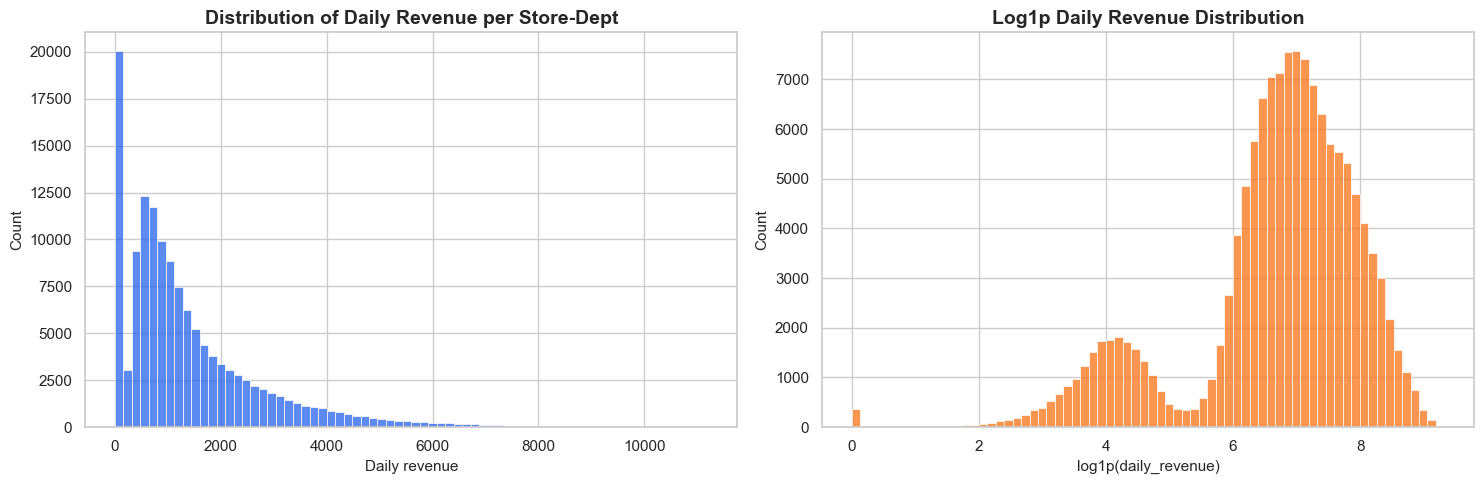

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["daily_revenue"], bins=70, color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Distribution of Daily Revenue per Store-Dept")
axes[0].set_xlabel("Daily revenue")

sns.histplot(np.log1p(df["daily_revenue"]), bins=70, color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title("Log1p Daily Revenue Distribution")
axes[1].set_xlabel("log1p(daily_revenue)")

plt.tight_layout()
plt.show()


**Insight chất lượng dữ liệu**

Dữ liệu sạch về key và coverage: không duplicate, không doanh thu âm. Zero revenue rất ít nên bài toán chủ yếu là regression cho demand/revenue liên tục, không phải zero-inflated forecasting như một số retail dataset khác. Phân phối revenue lệch phải, vì các department lớn như `FOODS_3` tại store mạnh có doanh thu rất cao.


## 6. Panel Coverage: M5 Là Daily Panel Đầy Đủ


In [6]:
calendar_days = (df["date"].max() - df["date"].min()).days + 1
expected_rows = df["date"].nunique() * df["store_id"].nunique() * df["dept_id"].nunique()

coverage_summary = pd.DataFrame([{
    "calendar_days": calendar_days,
    "unique_dates": df["date"].nunique(),
    "stores": df["store_id"].nunique(),
    "departments": df["dept_id"].nunique(),
    "expected_rows": expected_rows,
    "actual_rows": len(df),
    "coverage_rate": len(df) / expected_rows,
}])
display(coverage_summary)

store_coverage = (
    df.groupby(["store_id", "state_id"])
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        unique_dates=("date", "nunique"),
        rows=("date", "size"),
        depts=("dept_id", "nunique"),
        total_revenue=("daily_revenue", "sum"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
store_coverage["span_days"] = (store_coverage["last_date"] - store_coverage["first_date"]).dt.days + 1
store_coverage["coverage"] = store_coverage["unique_dates"] / store_coverage["span_days"]
display(store_coverage.round({"total_revenue": 2, "coverage": 3}))


,calendar_days,unique_dates,stores,departments,expected_rows,actual_rows,coverage_rate
0,1941,1941,10,7,135870,135870,1.0000


,store_id,state_id,first_date,last_date,unique_dates,rows,depts,total_revenue,span_days,coverage
2,CA_3,CA,2011-01-29,2016-05-22,1941,13587,7,"32,699,137.6800",1941,1.0000
0,CA_1,CA,2011-01-29,2016-05-22,1941,13587,7,"22,954,283.7800",1941,1.0000
5,TX_2,TX,2011-01-29,2016-05-22,1941,13587,7,"20,893,002.1900",1941,1.0000
6,TX_3,TX,2011-01-29,2016-05-22,1941,13587,7,"18,190,298.7000",1941,1.0000
8,WI_2,WI,2011-01-29,2016-05-22,1941,13587,7,"18,131,985.0400",1941,1.0000
1,CA_2,CA,2011-01-29,2016-05-22,1941,13587,7,"17,848,209.3900",1941,1.0000
9,WI_3,WI,2011-01-29,2016-05-22,1941,13587,7,"17,250,126.1800",1941,1.0000
4,TX_1,TX,2011-01-29,2016-05-22,1941,13587,7,"16,037,341.1500",1941,1.0000
7,WI_1,WI,2011-01-29,2016-05-22,1941,13587,7,"15,107,433.8100",1941,1.0000
3,CA_4,CA,2011-01-29,2016-05-22,1941,13587,7,"12,465,728.2000",1941,1.0000


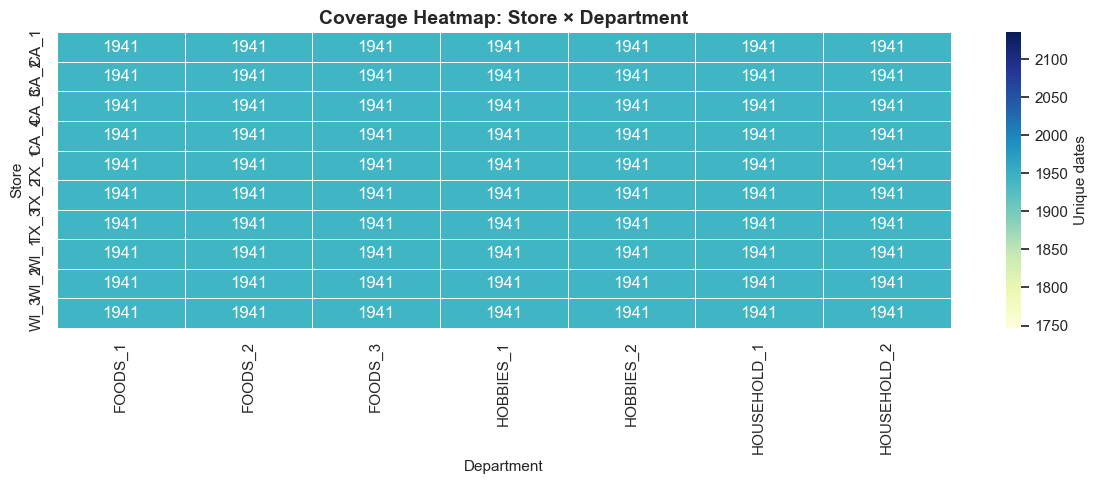

In [7]:
store_dept_dates = df.groupby(["store_id", "dept_id"])["date"].nunique().unstack("dept_id")

plt.figure(figsize=(12, 5))
sns.heatmap(store_dept_dates, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.4, cbar_kws={"label": "Unique dates"})
plt.title("Coverage Heatmap: Store × Department")
plt.xlabel("Department")
plt.ylabel("Store")
plt.tight_layout()
plt.show()


**Insight coverage**

Mỗi `store × dept` có đủ 1,941 ngày. Đây là điểm khác Maven: không cần xử lý sampled days hoặc tạo zero product rows. Daily history features như lag 7 và lag 28 có ý nghĩa rất tự nhiên.


## 7. Revenue By Category, Department Và Store


,cat_id,rows,total_revenue,total_units,mean_revenue,zero_rate,revenue_share
0,FOODS,58230,"111,140,025.4800",45922427,"1,908.6400",0.0022,0.5800
2,HOUSEHOLD,38820,"57,115,876.4200",14764090,"1,471.3000",0.0027,0.2980
1,HOBBIES,38820,"23,321,644.2200",6240656,600.7600,0.0034,0.1220


,cat_id,dept_id,total_revenue,total_units,mean_revenue,median_revenue,zero_rate,item_count
2,FOODS,FOODS_3,"72,345,863.7800",32937002,"3,727.2500","3,440.6800",0.0012,823
5,HOUSEHOLD,HOUSEHOLD_1,"42,132,778.5500",11722853,"2,170.6700","1,963.5200",0.0026,532
1,FOODS,FOODS_2,"25,592,365.6400",7795025,"1,318.5100","1,226.6200",0.0029,398
3,HOBBIES,HOBBIES_1,"22,120,244.5100",5699014,"1,139.6300","1,025.9900",0.0026,416
6,HOUSEHOLD,HOUSEHOLD_2,"14,983,097.8700",3041237,771.9300,653.3300,0.0027,515
0,FOODS,FOODS_1,"13,201,796.0600",5190400,680.1500,631.0400,0.0025,216
4,HOBBIES,HOBBIES_2,"1,201,399.7100",541642,61.9000,55.7700,0.0042,149


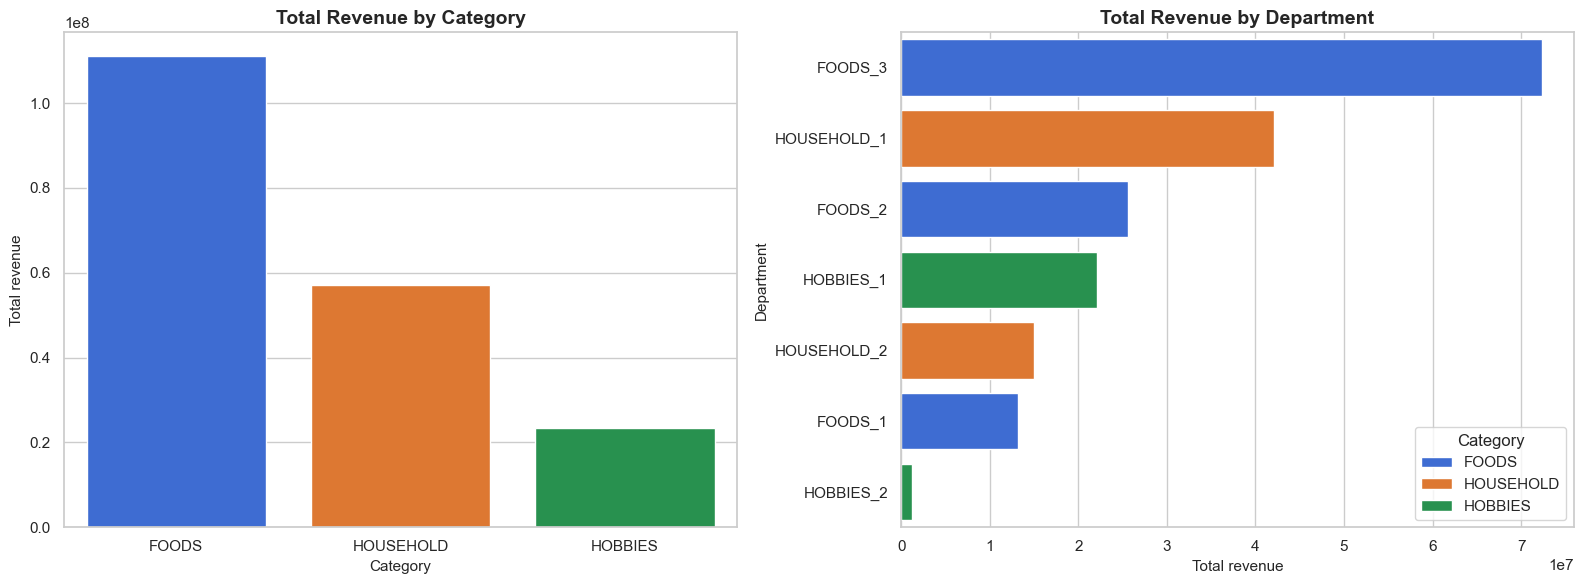

In [8]:
cat_summary = (
    df.groupby("cat_id")
    .agg(
        rows=("daily_revenue", "size"),
        total_revenue=("daily_revenue", "sum"),
        total_units=("daily_units", "sum"),
        mean_revenue=("daily_revenue", "mean"),
        zero_rate=("daily_revenue", lambda s: (s == 0).mean()),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
cat_summary["revenue_share"] = cat_summary["total_revenue"] / cat_summary["total_revenue"].sum()

dept_summary = (
    df.groupby(["cat_id", "dept_id"])
    .agg(
        total_revenue=("daily_revenue", "sum"),
        total_units=("daily_units", "sum"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        zero_rate=("daily_revenue", lambda s: (s == 0).mean()),
        item_count=("item_count", "first"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

display(cat_summary.round({"total_revenue": 2, "mean_revenue": 2, "zero_rate": 4, "revenue_share": 3}))
display(dept_summary.round({"total_revenue": 2, "mean_revenue": 2, "median_revenue": 2, "zero_rate": 4}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=cat_summary, x="cat_id", y="total_revenue", palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("Total Revenue by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total revenue")

sns.barplot(data=dept_summary, y="dept_id", x="total_revenue", hue="cat_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[1])
axes[1].set_title("Total Revenue by Department")
axes[1].set_xlabel("Total revenue")
axes[1].set_ylabel("Department")
axes[1].legend(title="Category")

plt.tight_layout()
plt.show()


,store_id,state_id,total_revenue,total_units,mean_revenue,zero_rate,revenue_share
2,CA_3,CA,"32,699,137.6800",11363540,"2,406.6500",0.0022,0.1710
0,CA_1,CA,"22,954,283.7800",7832248,"1,689.4300",0.0026,0.1200
5,TX_2,TX,"20,893,002.1900",7329642,"1,537.7200",0.0024,0.1090
6,TX_3,TX,"18,190,298.7000",6205940,"1,338.8000",0.0021,0.0950
8,WI_2,WI,"18,131,985.0400",6697988,"1,334.5100",0.0026,0.0950
1,CA_2,CA,"17,848,209.3900",5818395,"1,313.6200",0.0024,0.0930
9,WI_3,WI,"17,250,126.1800",6542557,"1,269.6100",0.0024,0.0900
4,TX_1,TX,"16,037,341.1500",5692823,"1,180.3400",0.0025,0.0840
7,WI_1,WI,"15,107,433.8100",5261506,"1,111.9000",0.0043,0.0790
3,CA_4,CA,"12,465,728.2000",4182534,917.4700,0.0033,0.0650


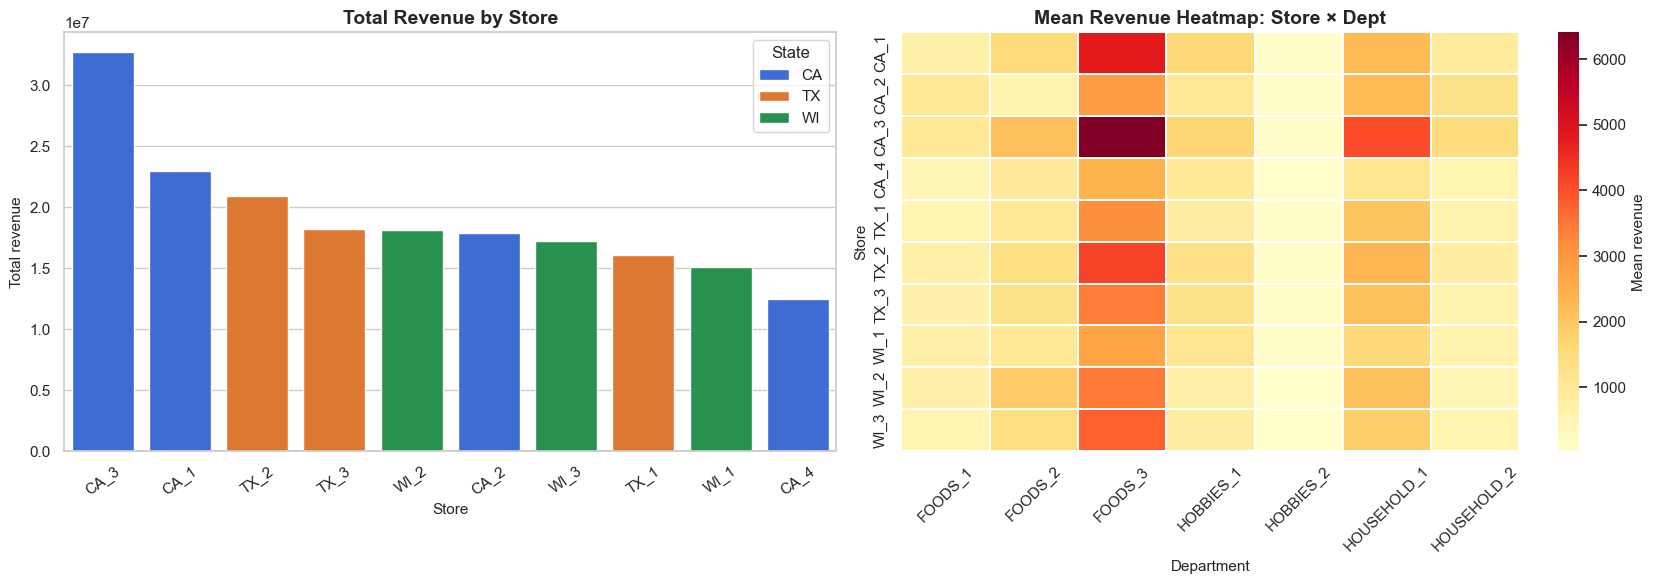

In [9]:
store_summary = (
    df.groupby(["store_id", "state_id"])
    .agg(
        total_revenue=("daily_revenue", "sum"),
        total_units=("daily_units", "sum"),
        mean_revenue=("daily_revenue", "mean"),
        zero_rate=("daily_revenue", lambda s: (s == 0).mean()),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
store_summary["revenue_share"] = store_summary["total_revenue"] / store_summary["total_revenue"].sum()

display(store_summary.round({"total_revenue": 2, "mean_revenue": 2, "zero_rate": 4, "revenue_share": 3}))

store_dept_heat = df.groupby(["store_id", "dept_id"])["daily_revenue"].mean().unstack("dept_id")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=store_summary, x="store_id", y="total_revenue", hue="state_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("Total Revenue by Store")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("Total revenue")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="State")

sns.heatmap(store_dept_heat, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Mean revenue"}, ax=axes[1])
axes[1].set_title("Mean Revenue Heatmap: Store × Dept")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Store")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Insight store/dept**

`FOODS` chiếm phần lớn doanh thu, đặc biệt `FOODS_3`. Store `CA_3` vượt trội so với phần còn lại và là nguồn của nhiều ngày doanh thu đỉnh. Heatmap cho thấy mỗi cặp `store × dept` có mức nền rất riêng, nên baseline theo store-dept chắc chắn sẽ mạnh hơn global/dept-only baseline.


## 8. Time Trend, Seasonality Và Day-Of-Week


,year,total_revenue,total_units,mean_revenue
0,2011,"23,891,336.1000",8856585,"1,012.7700"
1,2012,"32,649,200.8700",12061837,"1,274.3600"
2,2013,"35,923,373.3400",13135753,"1,406.0000"
3,2014,"37,861,913.2200",13089776,"1,481.8800"
4,2015,"42,416,456.5900",13800811,"1,660.1400"
5,2016,"18,835,265.9900",5982411,"1,881.6400"


,day_of_week_num,day_of_week,total_revenue,mean_revenue
0,0,Monday,"26,276,652.5100","1,355.1700"
1,1,Tuesday,"24,089,709.3500","1,242.3800"
2,2,Wednesday,"23,803,312.2800","1,227.6100"
3,3,Thursday,"23,908,468.5000","1,233.0300"
4,4,Friday,"27,053,857.7100","1,395.2500"
5,5,Saturday,"33,143,054.1100","1,703.1400"
6,6,Sunday,"33,302,491.6500","1,711.3300"


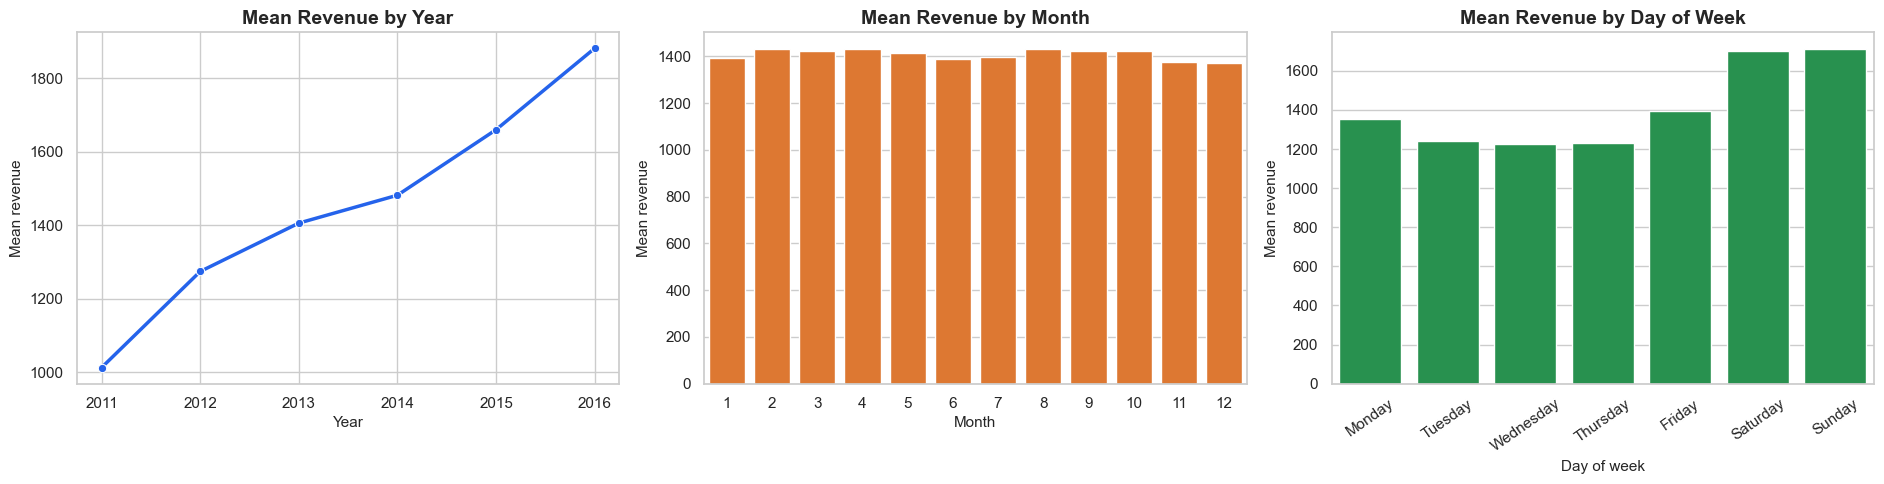

In [10]:
annual_summary = (
    df.groupby("year")
    .agg(total_revenue=("daily_revenue", "sum"), total_units=("daily_units", "sum"), mean_revenue=("daily_revenue", "mean"))
    .reset_index()
)

month_summary = (
    df.groupby("month")
    .agg(total_revenue=("daily_revenue", "sum"), mean_revenue=("daily_revenue", "mean"))
    .reset_index()
)

dow_summary = (
    df.groupby(["day_of_week_num", "day_of_week"])
    .agg(total_revenue=("daily_revenue", "sum"), mean_revenue=("daily_revenue", "mean"))
    .reset_index()
    .sort_values("day_of_week_num")
)

display(annual_summary.round(2))
display(dow_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.lineplot(data=annual_summary, x="year", y="mean_revenue", marker="o", linewidth=2.5, color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Mean Revenue by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean revenue")

sns.barplot(data=month_summary, x="month", y="mean_revenue", color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title("Mean Revenue by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean revenue")

sns.barplot(data=dow_summary, x="day_of_week", y="mean_revenue", color=COLOR_GREEN, ax=axes[2])
axes[2].set_title("Mean Revenue by Day of Week")
axes[2].set_xlabel("Day of week")
axes[2].set_ylabel("Mean revenue")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


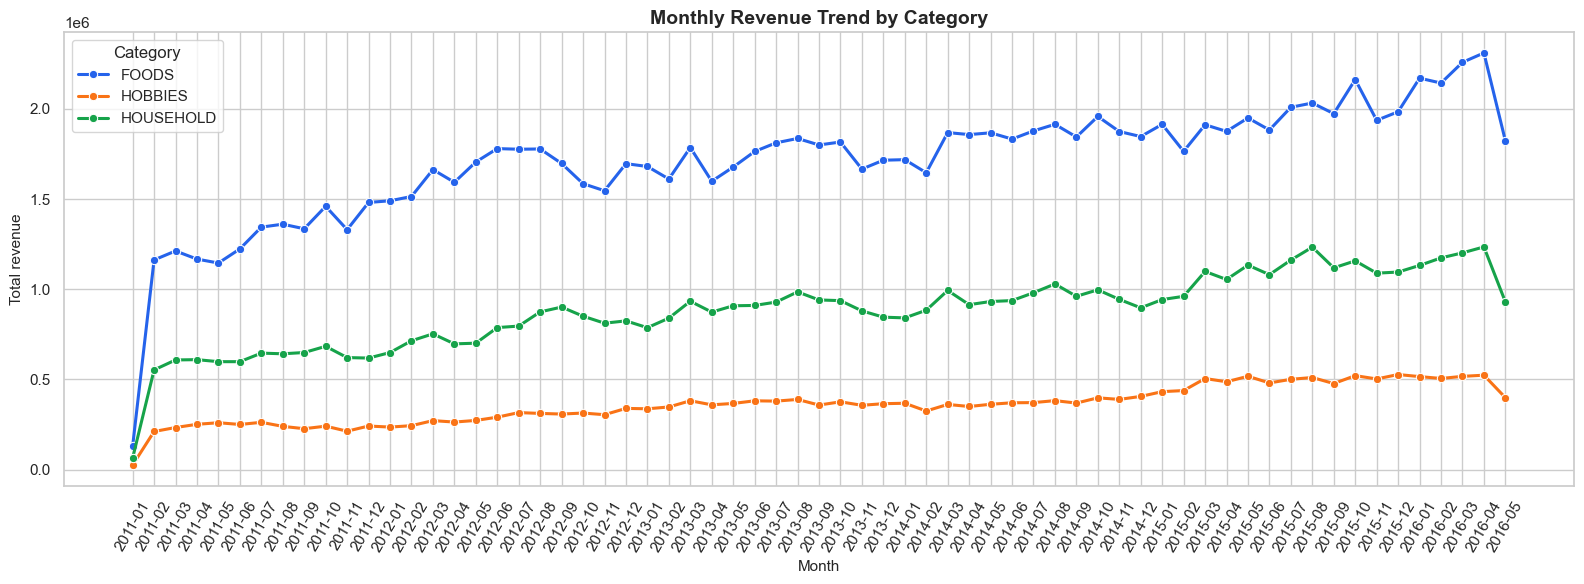

In [11]:
monthly_cat = (
    df.groupby([df["date"].dt.to_period("M").astype(str), "cat_id"])
    .agg(total_revenue=("daily_revenue", "sum"))
    .reset_index()
    .rename(columns={"date": "month_period"})
)

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_cat, x="month_period", y="total_revenue", hue="cat_id", marker="o", linewidth=2.2, palette=PALETTE_CONTRAST)
plt.title("Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Total revenue")
plt.xticks(rotation=60)
plt.legend(title="Category")
plt.tight_layout()
plt.show()


**Insight thời gian**

Doanh thu tăng rõ qua các năm. Năm 2016 chỉ có dữ liệu đến 22/05, nên tổng năm không so trực tiếp với các năm trước, nhưng mean revenue/row vẫn cao. Weekend effect rất mạnh: Saturday/Sunday cao hơn hẳn Tuesday-Thursday. Vì vậy lag 7, rolling 7 và day-of-week là feature quan trọng.


## 9. Event Và SNAP Analysis


,event_type_1,n_dates,rows,mean_revenue,median_revenue,total_revenue
4,Sporting,16,1120,"1,440.0300",996.2400,"1,612,830.2700"
0,Cultural,37,2590,"1,435.3600",999.2400,"3,717,592.3500"
3,Religious,54,3780,"1,416.6800",998.0400,"5,355,043.9500"
2,No Event,1783,124810,"1,414.8800",990.6700,"176,590,863.1900"
1,National,51,3570,"1,204.8200",738.4700,"4,301,216.3500"


,cat_id,snap_active,rows,mean_revenue,median_revenue
0,FOODS,0,39030,"1,800.0100","1,177.1800"
1,FOODS,1,19200,"2,129.4500","1,478.7600"
2,HOBBIES,0,26020,595.7600,194.5000
3,HOBBIES,1,12800,610.9400,205.3000
4,HOUSEHOLD,0,26020,"1,456.4100","1,190.9400"
5,HOUSEHOLD,1,12800,"1,501.5600","1,224.7800"


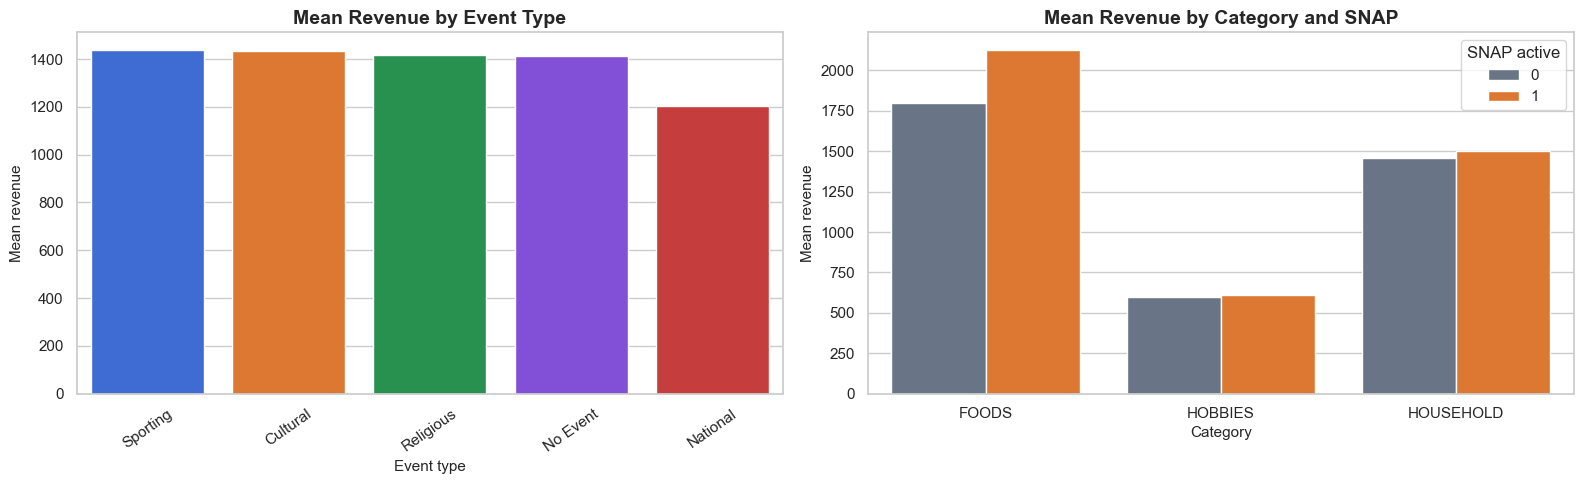

In [12]:
event_type_summary = (
    df.groupby("event_type_1")
    .agg(
        n_dates=("date", "nunique"),
        rows=("daily_revenue", "size"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        total_revenue=("daily_revenue", "sum"),
    )
    .reset_index()
    .sort_values("mean_revenue", ascending=False)
)

snap_cat_summary = (
    df.groupby(["cat_id", "snap_active"])
    .agg(rows=("daily_revenue", "size"), mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"))
    .reset_index()
)

display(event_type_summary.round(2))
display(snap_cat_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=event_type_summary, x="event_type_1", y="mean_revenue", palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("Mean Revenue by Event Type")
axes[0].set_xlabel("Event type")
axes[0].set_ylabel("Mean revenue")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=snap_cat_summary, x="cat_id", y="mean_revenue", hue="snap_active", palette=[COLOR_GRAY, COLOR_ACCENT], ax=axes[1])
axes[1].set_title("Mean Revenue by Category and SNAP")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Mean revenue")
axes[1].legend(title="SNAP active")

plt.tight_layout()
plt.show()


**Insight event/SNAP**

SNAP có signal rõ, đặc biệt với `FOODS`. Event type nhìn thô thì `National` thấp hơn, nhưng cần thận trọng vì ngày lễ có thể làm nhu cầu dịch chuyển sang trước/sau event. Dù vậy, event và SNAP là feature hợp lệ vì calendar tương lai thường biết trước.


## 10. Weather EDA


In [13]:
weather_numeric = [
    "temperature_max_c", "temperature_min_c", "temperature_mean_c", "apparent_temperature_mean_c",
    "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2",
]

weather_summary = df[weather_numeric].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(weather_summary.round(3))

weather_locations = df[["state_id", "weather_location_id", "location_name", "weather_spatial_level", "timezone"]].drop_duplicates()
display(weather_locations)

state_day = (
    df.groupby(["state_id", "date"])
    .agg(
        total_revenue=("daily_revenue", "sum"),
        temperature_mean_c=("temperature_mean_c", "first"),
        precipitation_mm=("precipitation_mm", "first"),
        snowfall_cm=("snowfall_cm", "first"),
        wind_speed_max_kmh=("wind_speed_max_kmh", "first"),
        is_weekend=("is_weekend", "first"),
        snap_active=("snap_active", "first"),
    )
    .reset_index()
)

weather_corr = state_day[["total_revenue", "temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh"]].corr()[["total_revenue"]].drop("total_revenue")
display(weather_corr.sort_values("total_revenue", key=lambda s: s.abs(), ascending=False).round(4))


,count,mean,std,min,1%,5%,50%,95%,99%,max
temperature_max_c,"135,870.0000",20.8920,10.7770,-17.6000,-7.7000,0.3000,22.7000,35.7000,38.8000,42.4000
temperature_min_c,"135,870.0000",11.1110,9.0940,-25.3000,-15.8000,-5.3000,11.6000,24.9000,28.1000,31.7000
temperature_mean_c,"135,870.0000",15.7060,9.6770,-22.9000,-11.2000,-2.5000,16.8000,29.8000,33.3000,37.2000
apparent_temperature_mean_c,"135,870.0000",14.1390,11.8190,-31.4000,-17.7000,-7.8000,15.2000,31.8000,35.3000,38.6000
precipitation_mm,"135,870.0000",1.6960,5.7740,0.0000,0.0000,0.0000,0.0000,10.0000,28.9000,85.5000
rain_mm,"135,870.0000",1.6000,5.6770,0.0000,0.0000,0.0000,0.0000,9.5000,28.8000,85.5000
snowfall_cm,"135,870.0000",0.0730,0.6060,0.0000,0.0000,0.0000,0.0000,0.0000,2.0300,14.6300
wind_speed_max_kmh,"135,870.0000",17.9260,7.0790,4.7000,7.7000,9.2000,15.8000,31.5000,37.2000,48.5000
wind_gusts_max_kmh,"135,870.0000",36.3680,11.4140,10.4000,17.3000,20.5000,34.2000,58.3000,71.3000,93.6000
shortwave_radiation_mj_m2,"135,870.0000",17.7210,7.7820,0.5400,1.9000,4.5100,17.7300,29.4900,30.8400,31.5700


,state_id,weather_location_id,location_name,weather_spatial_level,timezone
0,CA,m5_CA,"Los Angeles, CA",state_representative_city,America/Los_Angeles
28,TX,m5_TX,"Dallas, TX",state_representative_city,America/Chicago
49,WI,m5_WI,"Milwaukee, WI",state_representative_city,America/Chicago


,total_revenue
wind_speed_max_kmh,-0.4034
temperature_mean_c,0.1787
precipitation_mm,-0.1086
snowfall_cm,-0.1017


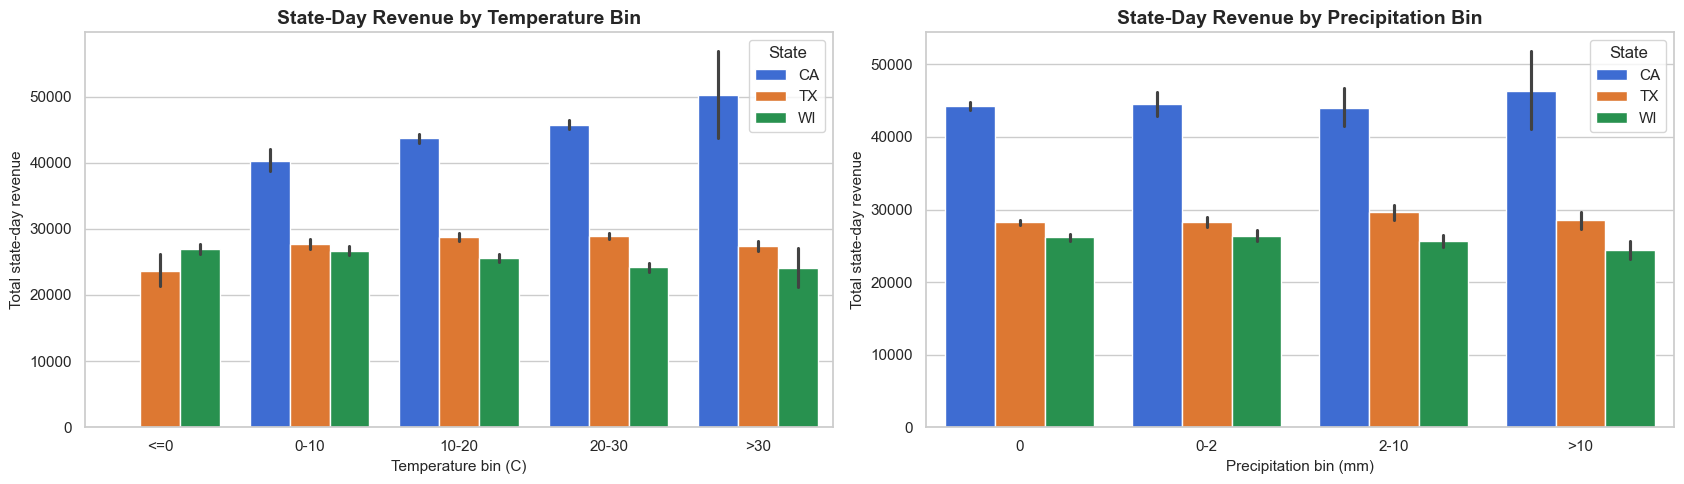

In [14]:
state_day["temp_bin"] = pd.cut(state_day["temperature_mean_c"], bins=[-30, 0, 10, 20, 30, 45], labels=["<=0", "0-10", "10-20", "20-30", ">30"])
state_day["precip_bin"] = pd.cut(state_day["precipitation_mm"], bins=[-0.01, 0, 2, 10, 100], labels=["0", "0-2", "2-10", ">10"])

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(data=state_day, x="temp_bin", y="total_revenue", hue="state_id", palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("State-Day Revenue by Temperature Bin")
axes[0].set_xlabel("Temperature bin (C)")
axes[0].set_ylabel("Total state-day revenue")
axes[0].legend(title="State")

sns.barplot(data=state_day, x="precip_bin", y="total_revenue", hue="state_id", palette=PALETTE_CONTRAST, ax=axes[1])
axes[1].set_title("State-Day Revenue by Precipitation Bin")
axes[1].set_xlabel("Precipitation bin (mm)")
axes[1].set_ylabel("Total state-day revenue")
axes[1].legend(title="State")

plt.tight_layout()
plt.show()


**Insight weather**

Weather có tín hiệu, nhưng không quá mạnh khi nhìn thô. Một phần vì weather được gán theo representative city của state, còn revenue chịu ảnh hưởng mạnh hơn bởi store/dept baseline và weekly seasonality. Vì vậy modeling sẽ kiểm định trực tiếp: no-weather vs with-weather.


## 11. Deep Data Understanding Và Kiểm Định Insight Theo `dept_id`

Phần này đào sâu hơn vào bản chất riêng của M5. Ở bài toán này, `dept_id` mới là nhóm sản phẩm chính cần dự báo. `cat_id` chỉ là tầng gom nhóm.

Để tránh bị đánh lừa bởi scale khác nhau giữa store/dept và trend theo năm, nhiều phân tích bên dưới dùng thêm:

```text
revenue_index = daily_revenue / median(daily_revenue của cùng store_id × dept_id × year)
```

Chỉ số này giúp so sánh pattern giữa department công bằng hơn. Ví dụ `FOODS_3` có doanh thu rất lớn, nhưng khi xét seasonality/SNAP/weekend, ta muốn biết nó tăng bao nhiêu so với mức bình thường của chính nó, không chỉ nhìn raw revenue.


In [15]:
eda_df = df.copy()
base_revenue = (
    eda_df.groupby(["store_id", "dept_id", "year"])["daily_revenue"]
    .transform("median")
    .replace(0, np.nan)
)
eda_df["revenue_index"] = eda_df["daily_revenue"] / base_revenue
eda_df["is_q4"] = eda_df["month"].isin([10, 11, 12]).astype(int)
eda_df["split"] = np.select(
    [eda_df["year"] <= 2014, eda_df["year"] == 2015, eda_df["year"] == 2016],
    ["train_2011_2014", "validation_2015", "test_2016"],
    default="other",
)

# Full-year data avoids partial-year bias from 2016 for seasonality/drift diagnostics.
full_year_df = eda_df[eda_df["year"] <= 2015].copy()

def mean_diff_ci_by_dept(data, group_col, positive_value=1):
    """Approximate 95% CI for mean index difference, aggregated at date level.

    This is a diagnostic confidence interval, not a causal proof.
    Aggregating by date reduces repeated-store duplication inside each department.
    """
    rows = []
    for dept_id, sub in data.groupby("dept_id"):
        date_level = (
            sub.groupby(["date", group_col])["revenue_index"]
            .mean()
            .reset_index()
        )
        a = date_level.loc[date_level[group_col] == positive_value, "revenue_index"].dropna().values
        b = date_level.loc[date_level[group_col] != positive_value, "revenue_index"].dropna().values
        diff = a.mean() - b.mean()
        se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
        rows.append({
            "dept_id": dept_id,
            "n_positive_days": len(a),
            "n_other_days": len(b),
            "mean_positive": a.mean(),
            "mean_other": b.mean(),
            "diff_index": diff,
            "ci_low": diff - 1.96 * se,
            "ci_high": diff + 1.96 * se,
            "lift_pct": (a.mean() / b.mean() - 1) * 100,
        })
    return pd.DataFrame(rows)

print("Revenue index sanity check:")
display(eda_df[["daily_revenue", "revenue_index"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.round(3))


Revenue index sanity check:


,count,mean,std,min,1%,5%,50%,95%,99%,max
daily_revenue,"135,870.0000","1,410.0060","1,384.2340",0.0000,15.3800,42.6350,985.7900,"4,258.8290","6,484.8790","11,198.9500"
revenue_index,"135,870.0000",1.0440,0.3720,0.0000,0.3750,0.6350,1.0000,1.5690,1.9680,17.9450


### 11.1. Department Profile: Scale, Concentration, Volatility

Câu hỏi: `dept_id` nào thật sự chi phối doanh thu? Có department nào quá nhỏ, quá volatile hoặc có zero-sales bất thường không?


,cat_id,dept_id,rows,total_revenue,mean_revenue,median_revenue,std_revenue,zero_rate,item_count,revenue_share,cv
2,FOODS,FOODS_3,19410,"72,345,863.7800","3,727.2500","3,440.6800","1,553.0300",0.0012,823,0.3780,0.4200
5,HOUSEHOLD,HOUSEHOLD_1,19410,"42,132,778.5500","2,170.6700","1,963.5200","1,067.0300",0.0026,532,0.2200,0.4900
1,FOODS,FOODS_2,19410,"25,592,365.6400","1,318.5100","1,226.6200",737.9400,0.0029,398,0.1340,0.5600
3,HOBBIES,HOBBIES_1,19410,"22,120,244.5100","1,139.6300","1,025.9900",532.6700,0.0026,416,0.1150,0.4700
6,HOUSEHOLD,HOUSEHOLD_2,19410,"14,983,097.8700",771.9300,653.3300,403.5500,0.0027,515,0.0780,0.5200
0,FOODS,FOODS_1,19410,"13,201,796.0600",680.1500,631.0400,288.1600,0.0025,216,0.0690,0.4200
4,HOBBIES,HOBBIES_2,19410,"1,201,399.7100",61.9000,55.7700,36.1300,0.0042,149,0.0060,0.5800


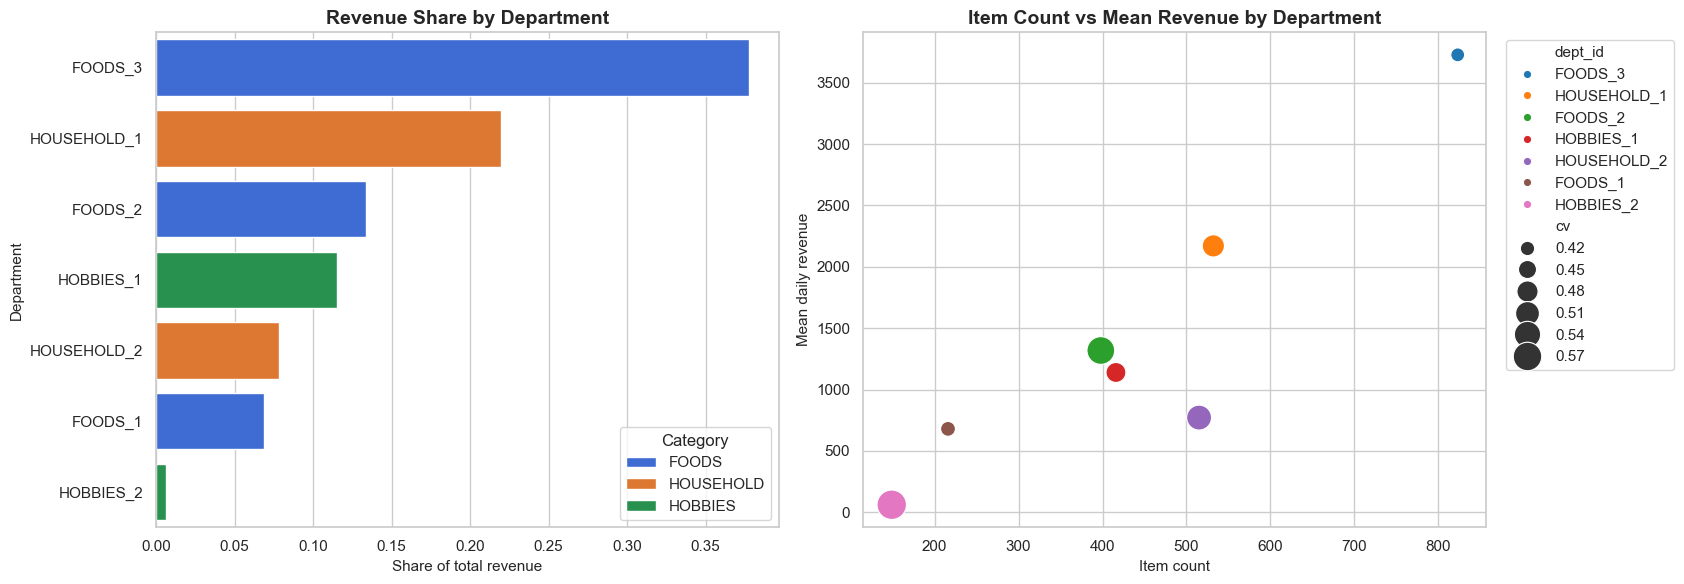

In [16]:
dept_profile = (
    eda_df.groupby(["cat_id", "dept_id"])
    .agg(
        rows=("daily_revenue", "size"),
        total_revenue=("daily_revenue", "sum"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        std_revenue=("daily_revenue", "std"),
        zero_rate=("daily_revenue", lambda s: (s == 0).mean()),
        item_count=("item_count", "first"),
    )
    .reset_index()
)
dept_profile["revenue_share"] = dept_profile["total_revenue"] / dept_profile["total_revenue"].sum()
dept_profile["cv"] = dept_profile["std_revenue"] / dept_profile["mean_revenue"]
dept_profile = dept_profile.sort_values("total_revenue", ascending=False)

display(dept_profile.round({
    "total_revenue": 2, "mean_revenue": 2, "median_revenue": 2,
    "std_revenue": 2, "zero_rate": 4, "revenue_share": 3, "cv": 2,
}))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.barplot(data=dept_profile, y="dept_id", x="revenue_share", hue="cat_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("Revenue Share by Department")
axes[0].set_xlabel("Share of total revenue")
axes[0].set_ylabel("Department")
axes[0].legend(title="Category")

sns.scatterplot(
    data=dept_profile,
    x="item_count",
    y="mean_revenue",
    size="cv",
    hue="dept_id",
    sizes=(100, 450),
    palette="tab10",
    ax=axes[1],
)
axes[1].set_title("Item Count vs Mean Revenue by Department")
axes[1].set_xlabel("Item count")
axes[1].set_ylabel("Mean daily revenue")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


**Insight**

`FOODS_3` là department áp đảo: khoảng 37-38% tổng doanh thu. `HOUSEHOLD_1` đứng thứ hai, còn `HOBBIES_2` gần như là long-tail department. Điều này có nghĩa là model tổng thể có thể nhìn rất tốt nhờ bắt được `FOODS_3`, nhưng khi đánh giá business thì vẫn phải xem lỗi riêng theo từng `dept_id`.

`item_count` có quan hệ với scale, nhưng không đủ giải thích tất cả: `HOBBIES_1` có nhiều item hơn `FOODS_2`, nhưng revenue thấp hơn. Nghĩa là nhu cầu, category type, store mix và lịch sử bán hàng mới là phần quan trọng hơn.


### 11.2. Store × Department Hidden Structure

Câu hỏi: doanh thu bị chi phối bởi vài cặp store-dept hay phân bổ đều? Nếu tập trung quá mạnh, model cần học baseline `store_id × dept_id` chứ không thể chỉ dùng category/dept trung bình.


,store_id,state_id,cat_id,dept_id,revenue,mean_revenue,revenue_share,cum_share
16,CA_3,CA,FOODS,FOODS_3,"12,441,318.3900","6,409.7500",0.0650,0.0650
2,CA_1,CA,FOODS,FOODS_3,"9,320,242.6200","4,801.7700",0.0490,0.1140
37,TX_2,TX,FOODS,FOODS_3,"8,172,091.2700","4,210.2500",0.0430,0.1560
19,CA_3,CA,HOUSEHOLD,HOUSEHOLD_1,"7,855,048.3800","4,046.9100",0.0410,0.1970
65,WI_3,WI,FOODS,FOODS_3,"7,319,263.6400","3,770.8700",0.0380,0.2350
58,WI_2,WI,FOODS,FOODS_3,"6,714,076.3000","3,459.0800",0.0350,0.2710
44,TX_3,TX,FOODS,FOODS_3,"6,650,708.6400","3,426.4300",0.0350,0.3050
30,TX_1,TX,FOODS,FOODS_3,"6,112,549.8700","3,149.1800",0.0320,0.3370
9,CA_2,CA,FOODS,FOODS_3,"5,662,971.2800","2,917.5500",0.0300,0.3670
51,WI_1,WI,FOODS,FOODS_3,"5,240,284.1700","2,699.7900",0.0270,0.3940


Top 10 store-dept combos revenue share: 0.394


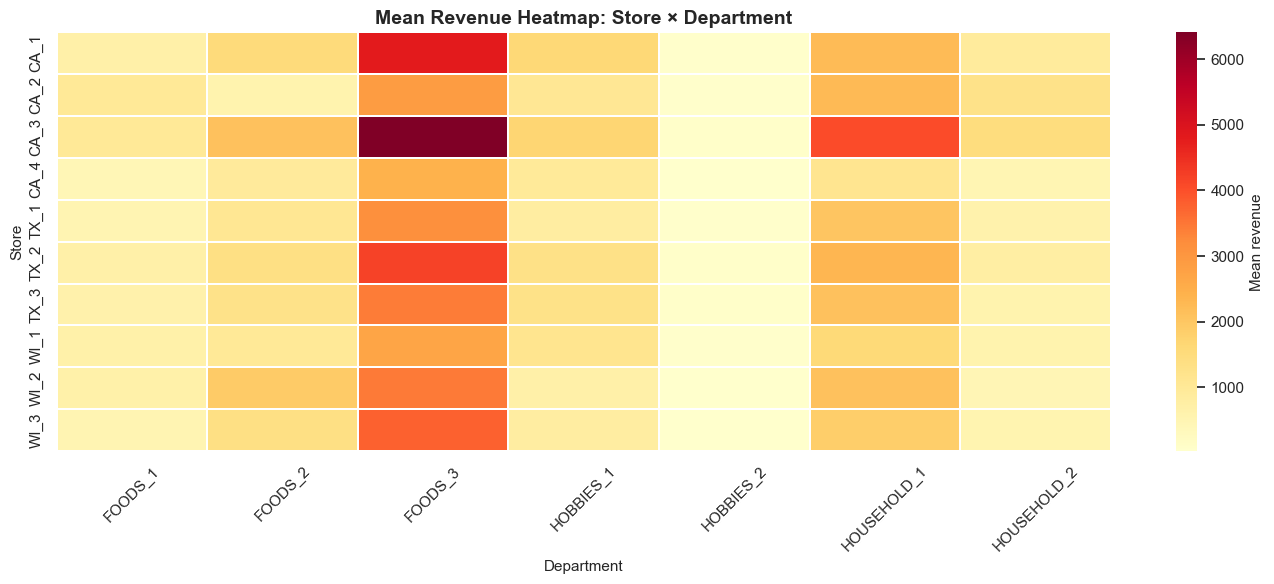

In [17]:
store_dept_profile = (
    eda_df.groupby(["store_id", "state_id", "cat_id", "dept_id"])
    .agg(revenue=("daily_revenue", "sum"), mean_revenue=("daily_revenue", "mean"))
    .reset_index()
    .sort_values("revenue", ascending=False)
)
store_dept_profile["revenue_share"] = store_dept_profile["revenue"] / store_dept_profile["revenue"].sum()
store_dept_profile["cum_share"] = store_dept_profile["revenue_share"].cumsum()

display(store_dept_profile.head(15).round({"revenue": 2, "mean_revenue": 2, "revenue_share": 3, "cum_share": 3}))
print("Top 10 store-dept combos revenue share:", round(store_dept_profile.head(10)["revenue_share"].sum(), 3))

store_dept_share_heat = (
    store_dept_profile.pivot(index="store_id", columns="dept_id", values="mean_revenue")
    .loc[sorted(eda_df["store_id"].unique())]
)

plt.figure(figsize=(14, 6))
sns.heatmap(store_dept_share_heat, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Mean revenue"})
plt.title("Mean Revenue Heatmap: Store × Department")
plt.xlabel("Department")
plt.ylabel("Store")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight**

Top 10 cặp store-dept đóng góp gần 40% tổng doanh thu. `CA_3 × FOODS_3` là cặp nổi bật nhất. Đây là bằng chứng trực tiếp cho việc phải đưa `store_id`, `dept_id` và các feature lịch sử theo `store_id × dept_id` vào model.


### 11.3. Department Seasonality: Không Phải Department Nào Cũng Tăng Cuối Năm

Câu hỏi: doanh thu theo tháng có pattern riêng theo từng `dept_id` không? Department nào bán mạnh cuối năm, department nào không?


,dept_id,peak_month,peak_index,trough_month,trough_index,amplitude_pct
4,HOBBIES_2,10,1.3120,7,0.9110,44.0000
1,FOODS_2,11,1.2790,4,0.9430,35.6000
5,HOUSEHOLD_1,9,1.1510,1,0.8990,28.0000
0,FOODS_1,12,1.1980,1,0.9460,26.7000
6,HOUSEHOLD_2,6,1.0930,1,0.8990,21.6000
3,HOBBIES_1,12,1.0690,1,0.9120,17.2000
2,FOODS_3,8,1.0810,1,0.9510,13.7000


is_q4,0,1,q4_lift_pct
dept_id,,,
HOBBIES_2,1.0070,1.2360,22.6930
FOODS_2,1.0250,1.2030,17.3840
FOODS_1,1.0050,1.0910,8.5130
HOUSEHOLD_1,1.0360,1.0890,5.1690
HOBBIES_1,1.0160,1.0490,3.2750
FOODS_3,1.0310,1.0500,1.8130
HOUSEHOLD_2,1.0520,0.9790,-6.8870


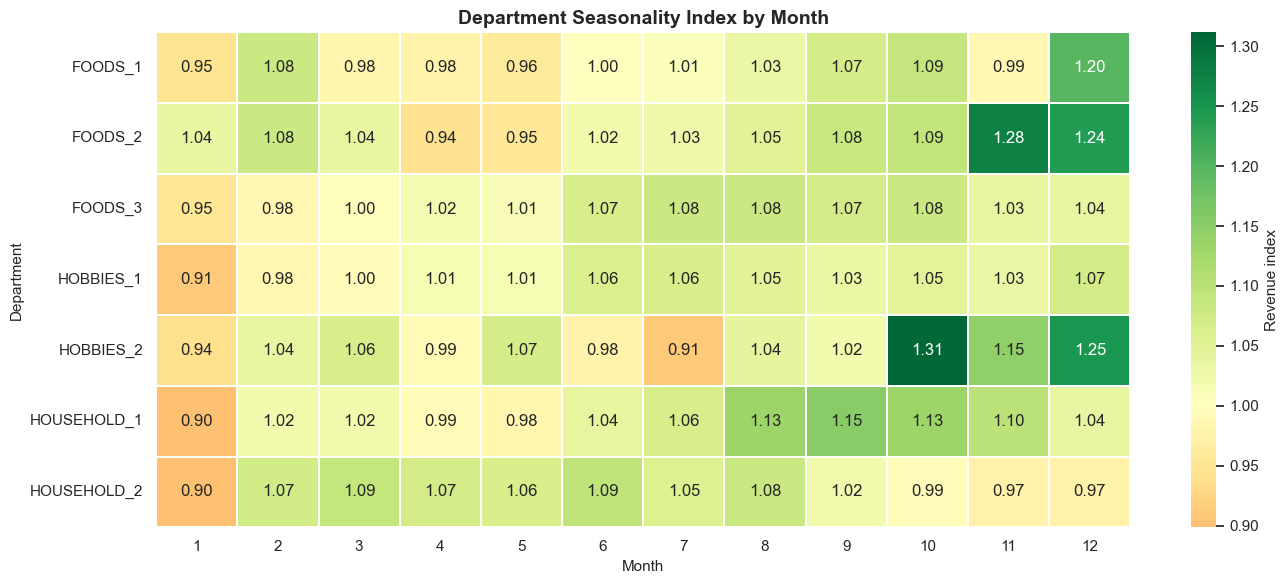

In [18]:
monthly_dept_index = (
    full_year_df.groupby(["dept_id", "month"])
    .agg(mean_index=("revenue_index", "mean"), mean_revenue=("daily_revenue", "mean"))
    .reset_index()
)

peak_month = monthly_dept_index.loc[
    monthly_dept_index.groupby("dept_id")["mean_index"].idxmax(),
    ["dept_id", "month", "mean_index"],
].rename(columns={"month": "peak_month", "mean_index": "peak_index"})

trough_month = monthly_dept_index.loc[
    monthly_dept_index.groupby("dept_id")["mean_index"].idxmin(),
    ["dept_id", "month", "mean_index"],
].rename(columns={"month": "trough_month", "mean_index": "trough_index"})

seasonality_summary = peak_month.merge(trough_month, on="dept_id")
seasonality_summary["amplitude_pct"] = (seasonality_summary["peak_index"] / seasonality_summary["trough_index"] - 1) * 100
seasonality_summary = seasonality_summary.sort_values("amplitude_pct", ascending=False)

display(seasonality_summary.round({"peak_index": 3, "trough_index": 3, "amplitude_pct": 1}))

q4_effect = full_year_df.groupby(["dept_id", "is_q4"])["revenue_index"].mean().unstack()
q4_effect["q4_lift_pct"] = (q4_effect[1] / q4_effect[0] - 1) * 100
q4_effect = q4_effect.sort_values("q4_lift_pct", ascending=False)
display(q4_effect.round(3))

pivot_month_index = monthly_dept_index.pivot(index="dept_id", columns="month", values="mean_index")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_month_index, cmap="RdYlGn", center=1.0, linewidths=0.3, annot=True, fmt=".2f", cbar_kws={"label": "Revenue index"})
plt.title("Department Seasonality Index by Month")
plt.xlabel("Month")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


**Insight có minh chứng**

Pattern cuối năm không đồng đều:

- `HOBBIES_2` và `FOODS_2` có Q4 lift mạnh nhất.
- `FOODS_1` cũng tăng rõ vào tháng 12.
- `HOUSEHOLD_2` lại giảm trong Q4 so với các tháng còn lại.
- `FOODS_3` là department lớn nhất nhưng seasonality theo tháng khá ổn định, biên độ thấp hơn nhiều department nhỏ.

Vì vậy không nên dùng một seasonality chung cho toàn bộ dataset. Feature `month` cần tương tác với `dept_id`, và model one-hot `dept_id + month` có thể học một phần tương tác này.


### 11.4. Weekend Effect: Kiểm Định Bằng Approximate Confidence Interval

Giả thuyết H1:

> Doanh thu cuối tuần cao hơn weekday sau khi normalize theo `store_id × dept_id × year`.

Ta kiểm định bằng revenue index, aggregate ở mức date trong từng department, rồi tính chênh lệch trung bình và approximate 95% CI.


,dept_id,n_positive_days,n_other_days,mean_positive,mean_other,diff_index,ci_low,ci_high,lift_pct
5,HOUSEHOLD_1,514,1284,1.3180,0.9420,0.3760,0.3600,0.3920,39.9000
6,HOUSEHOLD_2,514,1284,1.2730,0.9370,0.3360,0.3220,0.3490,35.8000
2,FOODS_3,514,1284,1.2550,0.9490,0.3060,0.2920,0.3200,32.3000
1,FOODS_2,514,1284,1.2650,0.9930,0.2720,0.2400,0.3040,27.4000
3,HOBBIES_1,514,1284,1.2140,0.9490,0.2650,0.2520,0.2790,28.0000
4,HOBBIES_2,514,1284,1.1920,1.0150,0.1770,0.1480,0.2060,17.4000
0,FOODS_1,514,1284,1.1400,0.9820,0.1580,0.1400,0.1760,16.1000


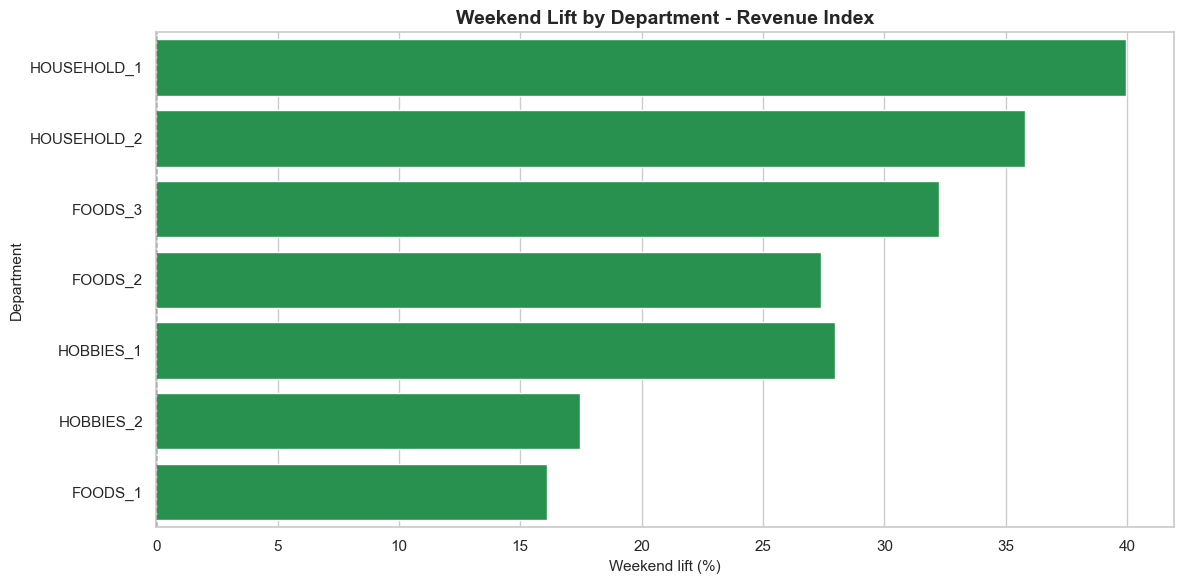

In [19]:
weekend_ci = mean_diff_ci_by_dept(full_year_df, "is_weekend", positive_value=1).sort_values("diff_index", ascending=False)
display(weekend_ci.round({
    "mean_positive": 3, "mean_other": 3, "diff_index": 3,
    "ci_low": 3, "ci_high": 3, "lift_pct": 1,
}))

plt.figure(figsize=(12, 6))
sns.barplot(data=weekend_ci, y="dept_id", x="lift_pct", color=COLOR_GREEN)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Weekend Lift by Department - Revenue Index")
plt.xlabel("Weekend lift (%)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


**Kết luận H1**

Chấp nhận giả thuyết theo hướng diagnostic: tất cả department đều có weekend lift dương và CI không cắt 0. Weekend effect mạnh nhất ở `HOUSEHOLD_1`, `HOUSEHOLD_2`, `FOODS_3`; yếu hơn ở `FOODS_1` và `HOBBIES_2` nhưng vẫn rõ.

Điều này giải thích vì sao `lag_7`, `day_of_week_num`, `is_weekend` và rolling theo tuần là feature quan trọng.


### 11.5. SNAP Effect: Tác Động Không Đều Theo Department

Giả thuyết H2:

> SNAP làm tăng doanh thu, nhưng tác động tập trung vào nhóm thực phẩm hơn là toàn bộ department.


,dept_id,n_positive_days,n_other_days,mean_positive,mean_other,diff_index,ci_low,ci_high,lift_pct
1,FOODS_2,885,1562,1.2740,0.9930,0.2810,0.2530,0.3100,28.3000
2,FOODS_3,885,1562,1.1370,0.9960,0.1410,0.1250,0.1560,14.1000
0,FOODS_1,885,1562,1.0730,1.0100,0.0630,0.0470,0.0790,6.2000
6,HOUSEHOLD_2,885,1562,1.0470,1.0310,0.0160,-0.0010,0.0330,1.6000
5,HOUSEHOLD_1,885,1562,1.0640,1.0490,0.0150,-0.0040,0.0340,1.4000
3,HOBBIES_1,885,1562,1.0370,1.0240,0.0120,-0.0030,0.0270,1.2000
4,HOBBIES_2,885,1562,1.0660,1.0650,0.0010,-0.0220,0.0250,0.1000


snap_active               0      1  lift_pct
dept_id     state_id                        
FOODS_2     WI       1.0290 1.4800   43.7440
            TX       0.9240 1.2340   33.4480
FOODS_3     WI       0.9660 1.2030   24.5630
FOODS_2     CA       0.9690 1.1360   17.1620
FOODS_3     TX       0.9830 1.1270   14.6290
FOODS_1     WI       0.9870 1.0990   11.3840
FOODS_3     CA       1.0090 1.0880    7.7960
FOODS_1     TX       1.0060 1.0760    6.9030
HOUSEHOLD_1 WI       1.0410 1.0730    3.0740
HOUSEHOLD_2 CA       1.0320 1.0610    2.7900
HOUSEHOLD_1 CA       1.0450 1.0720    2.6560
HOBBIES_1   CA       1.0090 1.0360    2.6450
HOUSEHOLD_1 TX       1.0330 1.0600    2.6170
HOUSEHOLD_2 WI       1.0180 1.0410    2.2640
HOBBIES_1   WI       1.0280 1.0480    1.9250

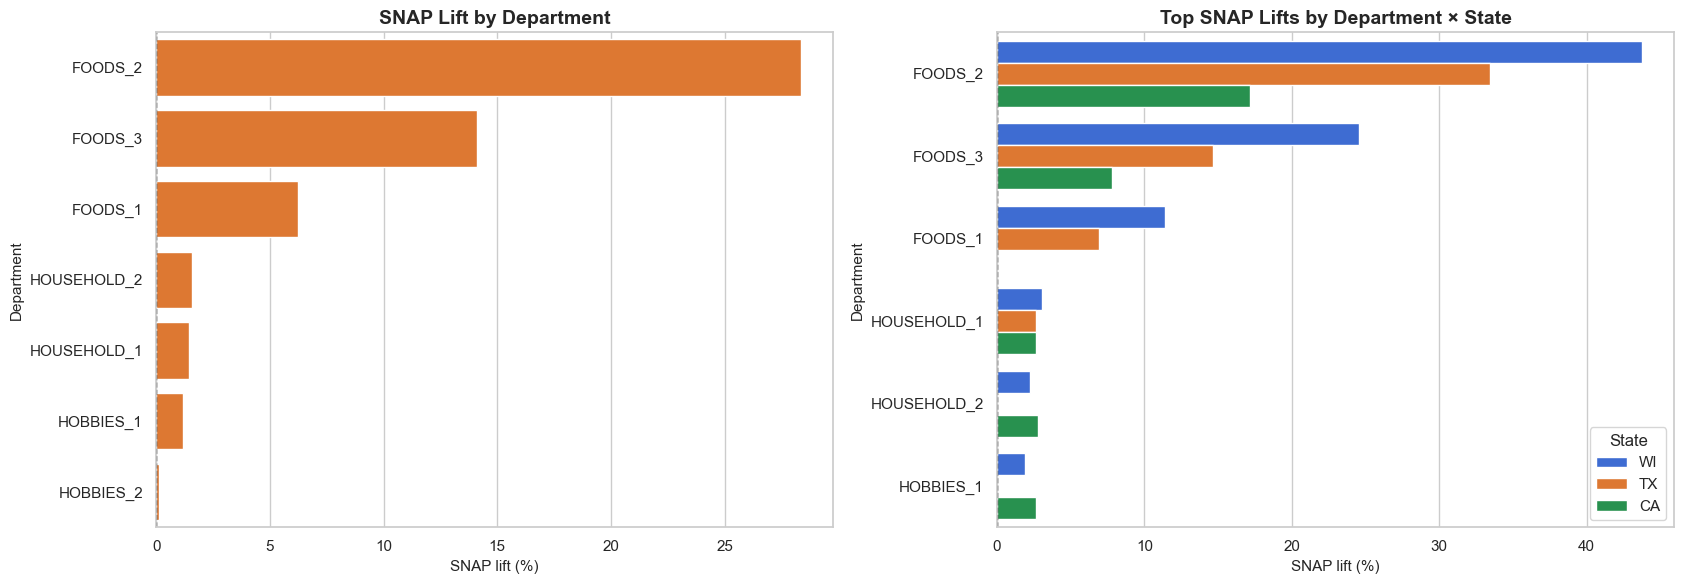

In [20]:
snap_ci = mean_diff_ci_by_dept(full_year_df, "snap_active", positive_value=1).sort_values("diff_index", ascending=False)
display(snap_ci.round({
    "mean_positive": 3, "mean_other": 3, "diff_index": 3,
    "ci_low": 3, "ci_high": 3, "lift_pct": 1,
}))

snap_state_effect = (
    full_year_df.groupby(["dept_id", "state_id", "snap_active"])["revenue_index"]
    .mean()
    .unstack()
)
snap_state_effect["lift_pct"] = (snap_state_effect[1] / snap_state_effect[0] - 1) * 100
snap_state_effect = snap_state_effect.sort_values("lift_pct", ascending=False)
display(snap_state_effect.round(3).head(15))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=snap_ci, y="dept_id", x="lift_pct", color=COLOR_ACCENT, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("SNAP Lift by Department")
axes[0].set_xlabel("SNAP lift (%)")
axes[0].set_ylabel("Department")

snap_state_plot = snap_state_effect.reset_index()
sns.barplot(data=snap_state_plot.head(15), y="dept_id", x="lift_pct", hue="state_id", palette=PALETTE_CONTRAST, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Top SNAP Lifts by Department × State")
axes[1].set_xlabel("SNAP lift (%)")
axes[1].set_ylabel("Department")
axes[1].legend(title="State")

plt.tight_layout()
plt.show()


**Kết luận H2**

SNAP không phải hiệu ứng chung cho mọi department. `FOODS_2` có lift lớn nhất, tiếp theo là `FOODS_3`; `FOODS_1` tăng nhẹ. Các department `HOUSEHOLD` và `HOBBIES` có lift nhỏ, nhiều CI gần hoặc cắt 0.

Điểm thú vị: `FOODS_2` ở WI/TX có SNAP lift rất mạnh. Đây là signal business rõ ràng: SNAP nên được giữ trong model, nhưng model cần biết `dept_id` và `state_id` để học tác động khác nhau.


### 11.6. Event Effect: National Holidays Là Ngày Doanh Thu Thấp Trên Hầu Hết Department

Giả thuyết H3:

> Event không chỉ là nhiễu lịch; một số loại event có pattern doanh thu riêng theo department.


event_type_1,Cultural,National,No Event,Religious,Sporting
dept_id,,,,,
FOODS_1,1.1490,0.8200,1.0310,1.0140,1.0390
FOODS_2,0.9690,0.8900,1.0770,1.0740,1.1170
FOODS_3,1.0440,0.9190,1.0390,1.0330,1.1030
HOBBIES_1,0.9850,0.7990,1.0330,1.0010,0.9820
HOBBIES_2,1.0440,0.8320,1.0740,1.0350,1.0170
HOUSEHOLD_1,0.9720,0.8690,1.0570,1.0250,1.0070
HOUSEHOLD_2,1.0370,0.8280,1.0390,1.0420,1.0490


,national_vs_no_event_pct
dept_id,
HOBBIES_1,-22.6000
HOBBIES_2,-22.6000
FOODS_1,-20.5000
HOUSEHOLD_2,-20.3000
HOUSEHOLD_1,-17.8000
FOODS_2,-17.4000
FOODS_3,-11.6000


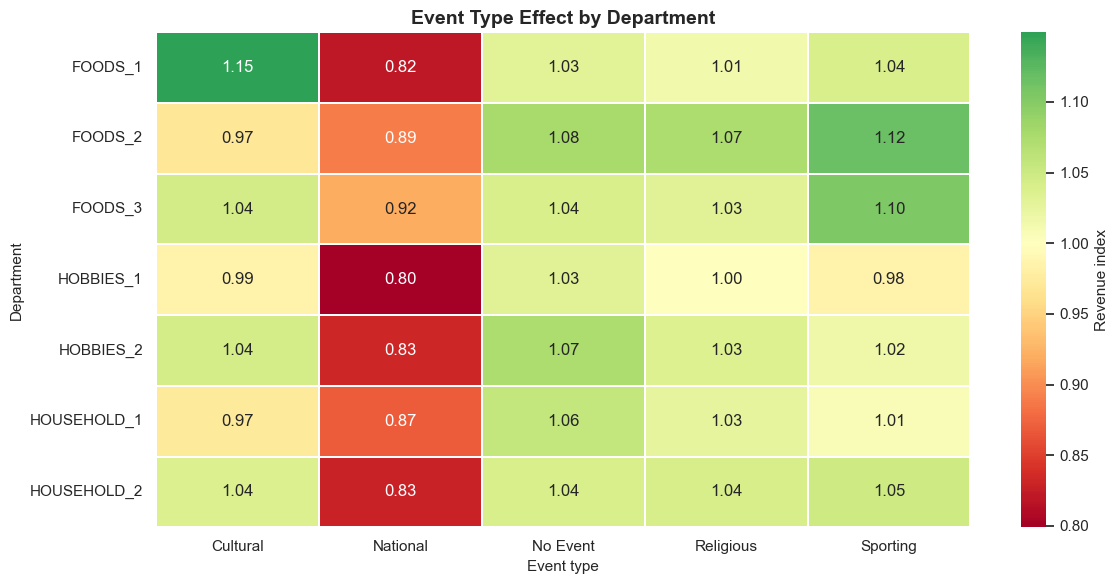

In [21]:
event_dept_index = (
    full_year_df.groupby(["dept_id", "event_type_1"])
    .agg(n=("revenue_index", "size"), mean_index=("revenue_index", "mean"))
    .reset_index()
)
event_pivot = event_dept_index.pivot(index="dept_id", columns="event_type_1", values="mean_index")
display(event_pivot.round(3))

if "National" in event_pivot.columns and "No Event" in event_pivot.columns:
    national_effect = ((event_pivot["National"] / event_pivot["No Event"] - 1) * 100).sort_values()
    display(national_effect.rename("national_vs_no_event_pct").round(1).to_frame())

plt.figure(figsize=(12, 6))
sns.heatmap(event_pivot, cmap="RdYlGn", center=1.0, annot=True, fmt=".2f", linewidths=0.3, cbar_kws={"label": "Revenue index"})
plt.title("Event Type Effect by Department")
plt.xlabel("Event type")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


**Kết luận H3**

`National` holidays thấp hơn `No Event` ở tất cả department, đặc biệt `HOBBIES_1`, `HOBBIES_2`, `FOODS_1`, `HOUSEHOLD_2`. Đây không nên hiểu vội là event “gây giảm doanh thu” theo nghĩa causal; có thể có hiệu ứng đóng cửa, mua trước ngày lễ, hoặc dịch chuyển nhu cầu.

Nhưng về forecast, event feature là hợp lệ và có signal. Hướng tốt hơn về sau là tạo thêm feature `days_before_event` và `days_after_event` để bắt pre/post holiday effect.


### 11.7. Trend Và Drift: Test 2016 Cao Hơn Validation 2015 Ở Hầu Hết Department

Câu hỏi: doanh thu có drift theo thời gian không? Nếu có, baseline trung bình lịch sử sẽ underpredict tương lai.


year,2011,2012,2013,2014,2015,2015_vs_2011_pct,2015_vs_2014_pct
dept_id,,,,,,,
HOBBIES_1,742.9000,899.2000,"1,148.9000","1,148.7000","1,532.8000",106.3000,33.4000
HOUSEHOLD_1,"1,389.2000","1,846.2000","2,195.8000","2,304.1000","2,726.8000",96.3000,18.3000
HOBBIES_2,44.2000,48.4000,55.2000,70.4000,82.7000,87.3000,17.5000
FOODS_1,462.4000,646.9000,689.6000,704.6000,797.1000,72.4000,13.1000
FOODS_2,994.0000,"1,132.3000","1,234.0000","1,311.8000","1,608.4000",61.8000,22.6000
FOODS_3,"2,801.8000","3,637.1000","3,764.4000","4,039.6000","4,004.2000",42.9000,-0.9000
HOUSEHOLD_2,654.9000,710.5000,754.0000,793.9000,868.9000,32.7000,9.4000


split,test_2016,train_2011_2014,validation_2015,test_vs_validation_pct
dept_id,,,,
FOODS_2,"2,052.8000","1,171.4000","1,608.4000",27.6000
FOODS_3,"4,539.6000","3,575.6000","4,004.2000",13.4000
FOODS_1,893.3000,629.1000,797.1000,12.1000
HOUSEHOLD_1,"3,018.8000","1,944.4000","2,726.8000",10.7000
HOUSEHOLD_2,947.3000,729.7000,868.9000,9.0000
HOBBIES_1,"1,639.6000",989.6000,"1,532.8000",7.0000
HOBBIES_2,80.3000,54.8000,82.7000,-3.0000


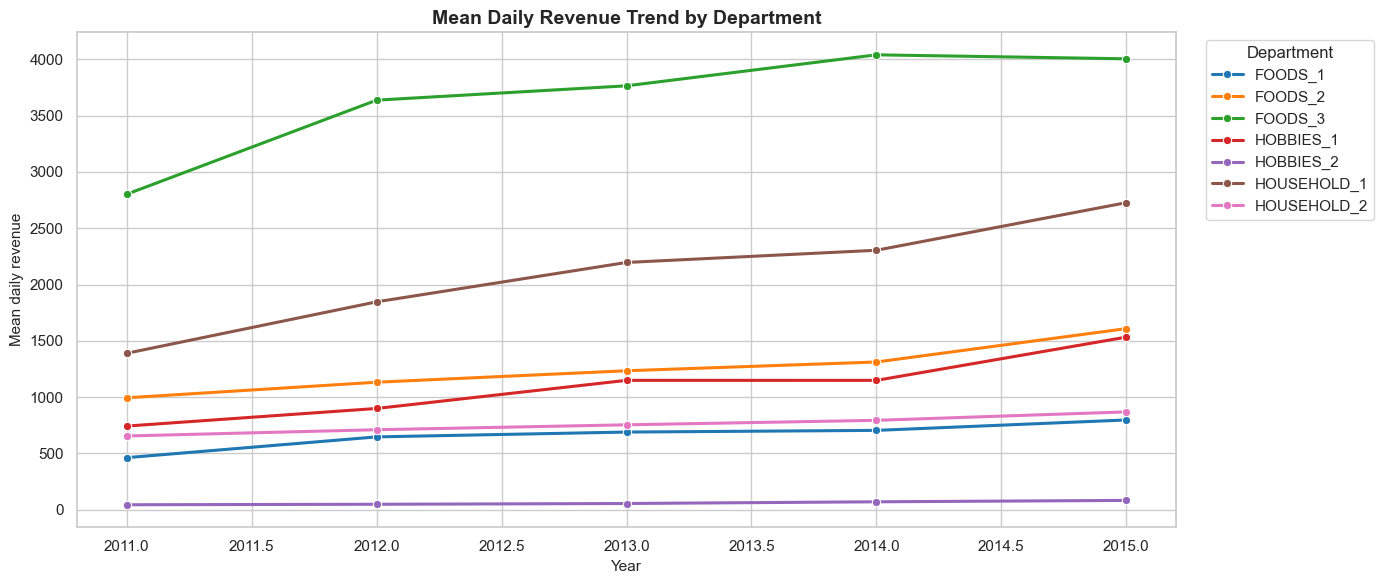

In [22]:
yearly_dept_mean = full_year_df.groupby(["dept_id", "year"])["daily_revenue"].mean().unstack()
yearly_dept_mean["2015_vs_2011_pct"] = (yearly_dept_mean[2015] / yearly_dept_mean[2011] - 1) * 100
yearly_dept_mean["2015_vs_2014_pct"] = (yearly_dept_mean[2015] / yearly_dept_mean[2014] - 1) * 100
yearly_dept_mean = yearly_dept_mean.sort_values("2015_vs_2011_pct", ascending=False)
display(yearly_dept_mean.round(1))

split_dept_mean = eda_df.groupby(["dept_id", "split"])["daily_revenue"].mean().unstack()
split_dept_mean["test_vs_validation_pct"] = (split_dept_mean["test_2016"] / split_dept_mean["validation_2015"] - 1) * 100
split_dept_mean = split_dept_mean.sort_values("test_vs_validation_pct", ascending=False)
display(split_dept_mean.round(1))

yearly_plot = (
    full_year_df.groupby(["year", "dept_id"])["daily_revenue"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_plot, x="year", y="daily_revenue", hue="dept_id", marker="o", linewidth=2.2, palette="tab10")
plt.title("Mean Daily Revenue Trend by Department")
plt.xlabel("Year")
plt.ylabel("Mean daily revenue")
plt.legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insight drift**

Từ 2011 đến 2015, hầu hết department tăng mạnh. `HOBBIES_1` và `HOUSEHOLD_1` tăng đặc biệt lớn. Test 2016 tiếp tục cao hơn validation 2015 ở hầu hết department, nhất là `FOODS_2`, `FOODS_3`, `FOODS_1`.

Điều này giải thích vì sao baseline `store_dept_mean` underpredict rất nặng trên test 2016. Model cần trend feature (`date_index`, `year`) và history gần nhất (`lag/rolling`) để bám mức doanh thu mới.


### 11.8. Lag Strength: Bằng Chứng Cho Feature Lịch Sử

Giả thuyết H4:

> Doanh thu hiện tại phụ thuộc mạnh vào doanh thu quá khứ của cùng `store_id × dept_id`, đặc biệt các lag theo chu kỳ tuần/tháng.


,dept_id,corr_lag_1,corr_lag_7,corr_lag_14,corr_lag_28,corr_lag_56
5,HOUSEHOLD_1,0.8530,0.9150,0.9140,0.9140,0.8890
6,HOUSEHOLD_2,0.8470,0.9130,0.9100,0.9030,0.8810
2,FOODS_3,0.8520,0.8780,0.8310,0.8950,0.8510
3,HOBBIES_1,0.8370,0.8840,0.8850,0.8830,0.8620
1,FOODS_2,0.8660,0.7790,0.6500,0.8690,0.7920
0,FOODS_1,0.8070,0.7710,0.7430,0.7510,0.7480
4,HOBBIES_2,0.6370,0.6100,0.5680,0.5340,0.5160


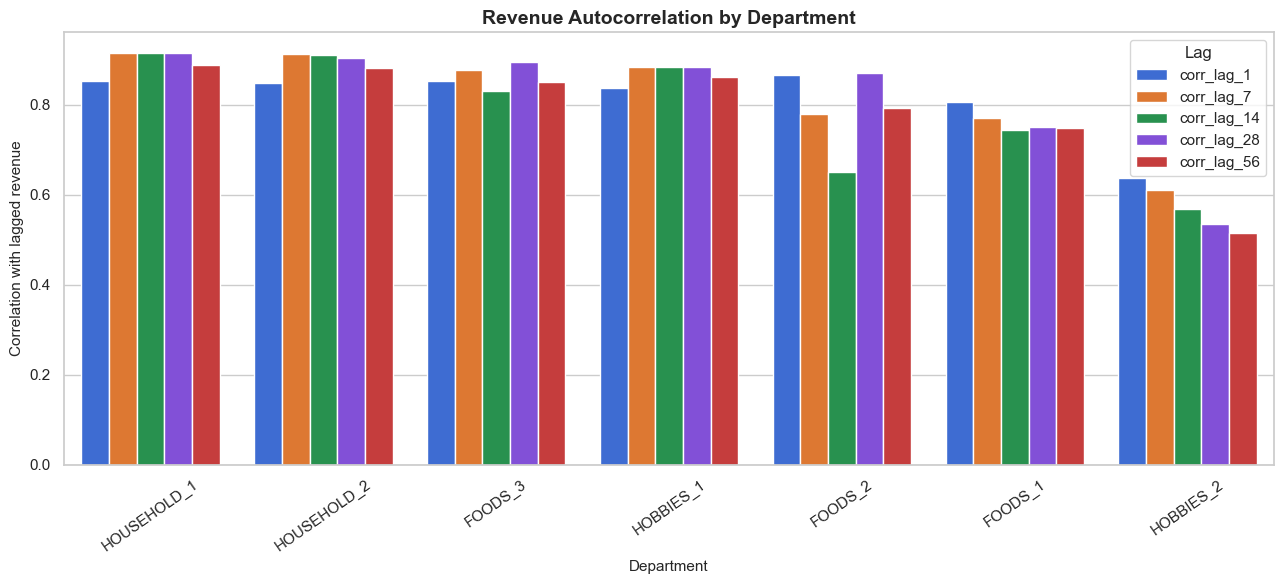

In [23]:
lag_check = eda_df.sort_values(["store_id", "dept_id", "date"]).copy()
lag_group = lag_check.groupby(["store_id", "dept_id"], sort=False)
for lag in [1, 7, 14, 28, 56]:
    lag_check[f"lag_{lag}"] = lag_group["daily_revenue"].shift(lag)

lag_corr_rows = []
for dept_id, sub in lag_check.groupby("dept_id"):
    row = {"dept_id": dept_id}
    for lag in [1, 7, 14, 28, 56]:
        tmp = sub[["daily_revenue", f"lag_{lag}"]].dropna()
        row[f"corr_lag_{lag}"] = tmp["daily_revenue"].corr(tmp[f"lag_{lag}"])
    lag_corr_rows.append(row)

lag_corr = pd.DataFrame(lag_corr_rows).sort_values("corr_lag_28", ascending=False)
display(lag_corr.round(3))

lag_corr_plot = lag_corr.melt(id_vars="dept_id", var_name="lag", value_name="correlation")
plt.figure(figsize=(13, 6))
sns.barplot(data=lag_corr_plot, x="dept_id", y="correlation", hue="lag", palette=PALETTE_CONTRAST)
plt.title("Revenue Autocorrelation by Department")
plt.xlabel("Department")
plt.ylabel("Correlation with lagged revenue")
plt.xticks(rotation=35)
plt.legend(title="Lag")
plt.tight_layout()
plt.show()


**Kết luận H4**

Lag correlation rất cao ở hầu hết department. `HOUSEHOLD_1`, `HOUSEHOLD_2`, `FOODS_3`, `HOBBIES_1` có correlation lag 7/28 đặc biệt mạnh. `HOBBIES_2` yếu hơn rõ vì scale nhỏ và nhiễu cao.

Đây là bằng chứng mạnh nhất cho hướng feature engineering: `lag_7`, `lag_28`, rolling 7/28/56 không chỉ là kỹ thuật, mà phản ánh quy luật thật của dữ liệu.


### 11.9. Weather Sau Khi Normalize: Tín Hiệu Trực Tiếp Yếu

Câu hỏi: weather có đủ mạnh để cải thiện forecast không, hay chỉ là signal phụ?


,temperature_mean_c,precipitation_mm,snowfall_cm,wind_speed_max_kmh,shortwave_radiation_mj_m2
dept_id,,,,,
FOODS_1,-0.0590,-0.0080,-0.0540,-0.0300,-0.0940
FOODS_2,-0.0900,0.0060,0.0150,0.0360,-0.1120
FOODS_3,0.1030,-0.0420,-0.0570,-0.0160,0.0780
HOBBIES_1,0.0570,-0.0270,-0.0800,-0.0110,0.0330
HOBBIES_2,-0.0720,-0.0020,-0.0380,-0.0040,-0.1150
HOUSEHOLD_1,0.0980,-0.0270,-0.0750,-0.0290,0.0270
HOUSEHOLD_2,0.0590,-0.0530,-0.0760,-0.0190,0.1550


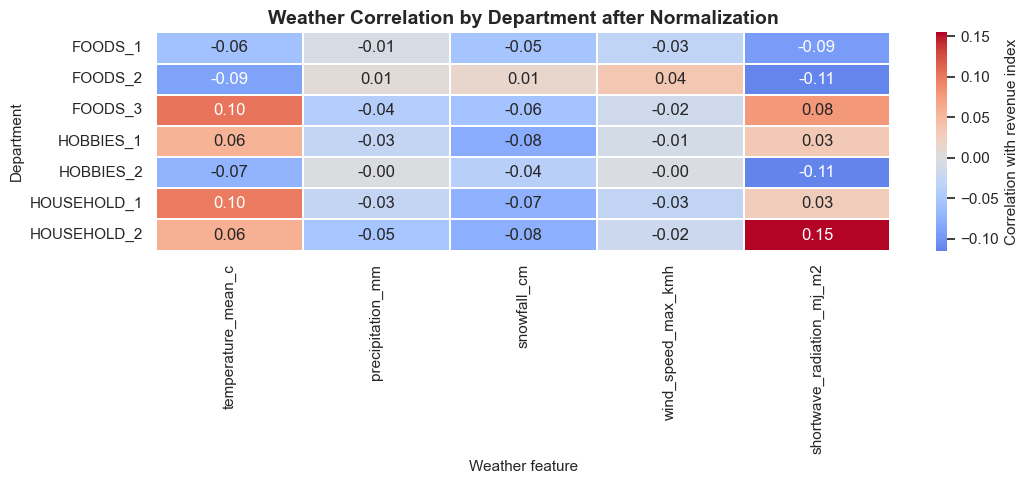

In [24]:
weather_signal_cols = ["temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh", "shortwave_radiation_mj_m2"]
weather_corr_rows = []
for dept_id, sub in full_year_df.groupby("dept_id"):
    row = {"dept_id": dept_id}
    for col in weather_signal_cols:
        row[col] = sub["revenue_index"].corr(sub[col])
    weather_corr_rows.append(row)

weather_corr_by_dept = pd.DataFrame(weather_corr_rows).set_index("dept_id")
display(weather_corr_by_dept.round(3))

plt.figure(figsize=(11, 5))
sns.heatmap(weather_corr_by_dept, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.3, cbar_kws={"label": "Correlation with revenue index"})
plt.title("Weather Correlation by Department after Normalization")
plt.xlabel("Weather feature")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


**Insight weather**

Sau khi normalize theo `store_id × dept_id × year`, tương quan weather với revenue index khá yếu. Một vài dấu hiệu có thể tồn tại theo department, nhưng không mạnh bằng weekend/SNAP/history. Điều này nhất quán với kết quả modeling: with-weather gần như không thắng no-weather.


### 11.10. Tổng Hợp Insight Trước Modeling

Các insight dưới đây là cơ sở cho feature engineering và lựa chọn model, không chỉ là quan sát mô tả.


In [25]:
deep_insight_summary = pd.DataFrame([
    {
        "finding": "Department scale rất lệch",
        "evidence": "FOODS_3 chiếm ~38% revenue, HOBBIES_2 chỉ ~0.6%",
        "model_implication": "Phải đánh giá lỗi theo dept_id; model tổng thể có thể bị FOODS_3 chi phối.",
    },
    {
        "finding": "Store × dept baseline rất mạnh",
        "evidence": "Top 10 store-dept combos chiếm ~39% revenue",
        "model_implication": "Cần store_id, dept_id và history theo store-dept.",
    },
    {
        "finding": "Seasonality khác nhau theo dept",
        "evidence": "HOBBIES_2 và FOODS_2 tăng Q4 mạnh; HOUSEHOLD_2 giảm Q4",
        "model_implication": "Không dùng một pattern tháng chung; cần dept_id + month/calendar interaction.",
    },
    {
        "finding": "Weekend effect robust",
        "evidence": "Tất cả dept có weekend lift dương, CI không cắt 0",
        "model_implication": "Giữ day_of_week/is_weekend và lag 7.",
    },
    {
        "finding": "SNAP chủ yếu tác động FOODS",
        "evidence": "FOODS_2 lift lớn nhất; HOUSEHOLD/HOBBIES lift nhỏ hoặc không rõ",
        "model_implication": "SNAP cần đi cùng dept/state để model học tác động khác nhau.",
    },
    {
        "finding": "National holidays thấp hơn No Event",
        "evidence": "National thấp hơn ở tất cả dept trên revenue_index",
        "model_implication": "Event feature hữu ích; nên cân nhắc lead/lag quanh holiday ở bản nâng cấp.",
    },
    {
        "finding": "Trend/drift tăng mạnh",
        "evidence": "2016 test cao hơn 2015 ở hầu hết dept, nhất là FOODS_2",
        "model_implication": "Mean baseline sẽ underpredict; cần date_index/year và history gần nhất.",
    },
    {
        "finding": "Lag/rolling là signal mạnh nhất",
        "evidence": "Lag 7/28 correlation cao ở hầu hết dept",
        "model_implication": "Feature engineering history là lõi của model.",
    },
    {
        "finding": "Weather trực tiếp yếu sau normalize",
        "evidence": "Weather correlations theo dept đa số nhỏ",
        "model_implication": "No-weather nên là model chính; with-weather là extension.",
    },
])

display(deep_insight_summary)


,finding,evidence,model_implication
0,Department scale rất lệch,"FOODS_3 chiếm ~38% revenue, HOBBIES_2 chỉ ~0.6%",Phải đánh giá lỗi theo dept_id; model tổng thể...
1,Store × dept baseline rất mạnh,Top 10 store-dept combos chiếm ~39% revenue,"Cần store_id, dept_id và history theo store-dept."
2,Seasonality khác nhau theo dept,HOBBIES_2 và FOODS_2 tăng Q4 mạnh; HOUSEHOLD_2...,Không dùng một pattern tháng chung; cần dept_i...
3,Weekend effect robust,"Tất cả dept có weekend lift dương, CI không cắt 0",Giữ day_of_week/is_weekend và lag 7.
4,SNAP chủ yếu tác động FOODS,FOODS_2 lift lớn nhất; HOUSEHOLD/HOBBIES lift ...,SNAP cần đi cùng dept/state để model học tác đ...
5,National holidays thấp hơn No Event,National thấp hơn ở tất cả dept trên revenue_i...,Event feature hữu ích; nên cân nhắc lead/lag q...
6,Trend/drift tăng mạnh,"2016 test cao hơn 2015 ở hầu hết dept, nhất là...",Mean baseline sẽ underpredict; cần date_index/...
7,Lag/rolling là signal mạnh nhất,Lag 7/28 correlation cao ở hầu hết dept,Feature engineering history là lõi của model.
8,Weather trực tiếp yếu sau normalize,Weather correlations theo dept đa số nhỏ,No-weather nên là model chính; with-weather là...


## 12. Feature Engineering Không Leakage


In [26]:
def prepare_model_frame(source_df):
    out = source_df.copy()

    # Clean event columns.
    for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
        out[col] = out[col].fillna("No Event").astype(str)

    # Calendar cyclic features.
    out["date_index"] = (out["date"] - out["date"].min()).dt.days + 1
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week_num"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week_num"] / 7)
    out["doy_sin"] = np.sin(2 * np.pi * out["day_of_year"] / 366)
    out["doy_cos"] = np.cos(2 * np.pi * out["day_of_year"] / 366)
    out["week_sin"] = np.sin(2 * np.pi * out["week_of_year"] / 53)
    out["week_cos"] = np.cos(2 * np.pi * out["week_of_year"] / 53)

    # Weather flags for with-weather model.
    out["is_rainy_day"] = (out["precipitation_mm"] > 0).astype(int)
    out["is_heavy_rain_day"] = (out["precipitation_mm"] >= 10).astype(int)
    out["is_snowy_day"] = (out["snowfall_cm"] > 0).astype(int)
    out["is_hot_day"] = (out["temperature_mean_c"] >= 30).astype(int)
    out["is_cold_day"] = (out["temperature_mean_c"] <= 0).astype(int)

    # History features. Everything is shifted before rolling to avoid same-day leakage.
    out = out.sort_values(["store_id", "dept_id", "date"]).reset_index(drop=True)
    group = out.groupby(["store_id", "dept_id"], sort=False)

    for lag in [1, 7, 14, 28, 56]:
        out[f"revenue_lag_{lag}"] = group["daily_revenue"].shift(lag)

    shifted = group["daily_revenue"].shift(1)
    for window in [7, 14, 28, 56]:
        out[f"revenue_roll_mean_{window}"] = (
            shifted.groupby([out["store_id"], out["dept_id"]])
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(level=[0, 1], drop=True)
        )

    for window in [7, 28]:
        out[f"revenue_roll_std_{window}"] = (
            shifted.groupby([out["store_id"], out["dept_id"]])
            .rolling(window, min_periods=2)
            .std()
            .reset_index(level=[0, 1], drop=True)
        )

    out["revenue_expanding_mean"] = group["daily_revenue"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    out["zero_sales_roll_28"] = (
        group["has_sales"].shift(1).rsub(1)
        .groupby([out["store_id"], out["dept_id"]])
        .rolling(28, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    return out


df_model = prepare_model_frame(df)

history_features = [
    "revenue_lag_1", "revenue_lag_7", "revenue_lag_14", "revenue_lag_28", "revenue_lag_56",
    "revenue_roll_mean_7", "revenue_roll_mean_14", "revenue_roll_mean_28", "revenue_roll_mean_56",
    "revenue_roll_std_7", "revenue_roll_std_28", "revenue_expanding_mean", "zero_sales_roll_28",
]

print("Model frame shape:", df_model.shape)
print("History feature missing counts:")
display(df_model[history_features].isna().sum().to_frame("missing_count"))

display(df_model[key_cols + ["daily_revenue"] + history_features[:8]].head(12))


Model frame shape: (135870, 83)
History feature missing counts:


,missing_count
revenue_lag_1,70
revenue_lag_7,490
revenue_lag_14,980
revenue_lag_28,1960
revenue_lag_56,3920
revenue_roll_mean_7,70
revenue_roll_mean_14,70
revenue_roll_mean_28,70
revenue_roll_mean_56,70
revenue_roll_std_7,140


,date,store_id,dept_id,daily_revenue,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_28,revenue_lag_56,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_28
0,2011-01-29,CA_1,FOODS_1,681.1800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-30,CA_1,FOODS_1,643.6900,681.1800,NaN,NaN,NaN,NaN,681.1800,681.1800,681.1800
2,2011-01-31,CA_1,FOODS_1,451.1400,643.6900,NaN,NaN,NaN,NaN,662.4350,662.4350,662.4350
3,2011-02-01,CA_1,FOODS_1,400.3900,451.1400,NaN,NaN,NaN,NaN,592.0033,592.0033,592.0033
4,2011-02-02,CA_1,FOODS_1,396.3600,400.3900,NaN,NaN,NaN,NaN,544.1000,544.1000,544.1000
5,2011-02-03,CA_1,FOODS_1,434.4000,396.3600,NaN,NaN,NaN,NaN,514.5520,514.5520,514.5520
6,2011-02-04,CA_1,FOODS_1,575.8100,434.4000,NaN,NaN,NaN,NaN,501.1933,501.1933,501.1933
7,2011-02-05,CA_1,FOODS_1,586.1500,575.8100,681.1800,NaN,NaN,NaN,511.8529,511.8529,511.8529
8,2011-02-06,CA_1,FOODS_1,595.4700,586.1500,643.6900,NaN,NaN,NaN,498.2771,521.1400,521.1400
9,2011-02-07,CA_1,FOODS_1,405.6300,595.4700,451.1400,NaN,NaN,NaN,491.3886,529.3989,529.3989


**Feature engineering insight**

Dữ liệu daily đầy đủ nên `lag_7` thực sự là cùng thứ trong tuần trước, còn `lag_28` gần với cùng weekday cách 4 tuần. Đây là lợi thế lớn so với Maven. Tất cả rolling đều dùng revenue đã shift trước, nên không có leakage từ ngày hiện tại.


## 13. Time-Based Split


In [27]:
train_df = df_model[df_model["year"] <= 2014].copy()
val_df = df_model[df_model["year"] == 2015].copy()
test_df = df_model[df_model["year"] == 2016].copy()
train_val_df = df_model[df_model["year"] <= 2015].copy()

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "train_plus_validation"],
    "date_min": [train_df.date.min(), val_df.date.min(), test_df.date.min(), train_val_df.date.min()],
    "date_max": [train_df.date.max(), val_df.date.max(), test_df.date.max(), train_val_df.date.max()],
    "rows": [len(train_df), len(val_df), len(test_df), len(train_val_df)],
    "unique_dates": [train_df.date.nunique(), val_df.date.nunique(), test_df.date.nunique(), train_val_df.date.nunique()],
})
display(split_summary)


,split,date_min,date_max,rows,unique_dates
0,train,2011-01-29,2014-12-31,100310,1433
1,validation,2015-01-01,2015-12-31,25550,365
2,test,2016-01-01,2016-05-22,10010,143
3,train_plus_validation,2011-01-29,2015-12-31,125860,1798


**Split strategy**

Split này mô phỏng forecasting tương lai tốt hơn random split. Validation 2015 dùng để chọn model, còn test 2016 chỉ dùng để báo kết quả cuối.


## 14. Baseline Models


In [28]:
def fit_mean_baselines(train):
    return {
        "global_mean": train["daily_revenue"].mean(),
        "dept_mean": train.groupby("dept_id")["daily_revenue"].mean(),
        "store_mean": train.groupby("store_id")["daily_revenue"].mean(),
        "store_dept_mean": train.groupby(["store_id", "dept_id"])["daily_revenue"].mean(),
    }


def map_group_mean(data, series, keys, fallback):
    idx = data.set_index(keys).index
    return pd.Series(idx.map(series), index=data.index).fillna(fallback).astype(float).values


def predict_mean_baseline(model, data, kind):
    if kind == "global_mean":
        return np.full(len(data), model["global_mean"])
    if kind == "dept_mean":
        return data["dept_id"].map(model["dept_mean"]).fillna(model["global_mean"]).values
    if kind == "store_mean":
        return data["store_id"].map(model["store_mean"]).fillna(model["global_mean"]).values
    if kind == "store_dept_mean":
        return map_group_mean(data, model["store_dept_mean"], ["store_id", "dept_id"], model["global_mean"])
    raise ValueError(kind)


def predict_history_baseline(train, data, history_col):
    model = fit_mean_baselines(train)
    fallback = map_group_mean(data, model["store_dept_mean"], ["store_id", "dept_id"], model["global_mean"])
    return data[history_col].fillna(pd.Series(fallback, index=data.index)).values

baseline_model = fit_mean_baselines(train_df)

baseline_rows = []
for name in ["global_mean", "dept_mean", "store_mean", "store_dept_mean"]:
    pred = predict_mean_baseline(baseline_model, val_df, name)
    baseline_rows.append({"model": name, **evaluate_regression(val_df["daily_revenue"], pred)})

for col in ["revenue_lag_1", "revenue_lag_7", "revenue_lag_28", "revenue_roll_mean_7", "revenue_roll_mean_28"]:
    pred = predict_history_baseline(train_df, val_df, col)
    baseline_rows.append({"model": col, **evaluate_regression(val_df["daily_revenue"], pred)})

val_baseline_results = display_metrics_table(baseline_rows)


,model,MAE,RMSE,WAPE,R2,Bias
6,revenue_lag_28,249.0650,411.6640,0.1500,0.9215,-16.2910
5,revenue_lag_7,266.5270,456.4310,0.1605,0.9034,-3.4430
7,revenue_roll_mean_7,290.7040,474.2310,0.1751,0.8958,-2.3780
8,revenue_roll_mean_28,296.9580,484.0100,0.1789,0.8914,-8.1630
4,revenue_lag_1,300.3080,511.0270,0.1809,0.8790,-1.1890
3,store_dept_mean,456.4280,723.5630,0.2749,0.7573,-360.9050
1,dept_mean,550.4410,919.8100,0.3316,0.6079,-360.9050
2,store_mean,"1,048.2760","1,456.2220",0.6314,0.0171,-360.9050
0,global_mean,"1,069.3610","1,512.5400",0.6441,-0.0604,-360.9050


**Baseline insight**

Các baseline history vượt rất xa mean baseline. Đặc biệt `revenue_lag_28` thường mạnh vì giữ được weekly pattern và làm mượt nhiễu hơn lag 1. Điều này xác nhận rằng bài toán M5 có tính lặp theo tuần/tháng rất mạnh.


## 15. LightGBM With Weather Only

Theo yêu cầu mới, phần train/evaluate chính chỉ sử dụng **một model duy nhất**:

**LightGBM with weather**

Tức là notebook không còn train `no_weather`, không còn so sánh nhiều model hoặc nhiều feature set. Model cuối dùng đầy đủ:

- Calendar/time features.
- SNAP/event features.
- Store/category/department metadata.
- `store_dept_id` interaction.
- Revenue history lag/rolling.
- Weather numeric/flag features.
- `weather_code` categorical.

`store_dept_id = store_id + "__" + dept_id` là feature hợp lệ vì đây là định danh biết trước, không phải leakage.

In [29]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

from lightgbm import LGBMRegressor

LIGHTGBM_PARAMS = {
    "objective": "regression_l1",
    "n_estimators": 700,
    "learning_rate": 0.04,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

print("Model used: LGBMRegressor with weather features only")
print("LightGBM params:")
for key, value in LIGHTGBM_PARAMS.items():
    print(f"- {key}: {value}")

# Explicit store-dept interaction. This is known before forecasting and is not leakage.
for frame in [df_model, train_df, val_df, test_df, train_val_df]:
    frame["store_dept_id"] = frame["store_id"].astype(str) + "__" + frame["dept_id"].astype(str)

numeric_base_features = [
    "item_count", "snap_active", "event_count", "date_index", "year",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos", "week_sin", "week_cos", "is_weekend",
]

numeric_history_features = history_features.copy()

numeric_weather_features = [
    "temperature_max_c", "temperature_min_c", "temperature_mean_c", "apparent_temperature_mean_c",
    "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2", "is_rainy_day", "is_heavy_rain_day", "is_snowy_day", "is_hot_day", "is_cold_day",
]

categorical_features = [
    "store_id", "state_id", "cat_id", "dept_id", "store_dept_id",
    "month", "day_of_week_num", "event_name_1", "event_type_1", "event_name_2", "event_type_2", "weather_code",
]


def keep_existing(cols, data=df_model):
    return [col for col in cols if col in data.columns]

numeric_features = keep_existing(numeric_base_features + numeric_history_features + numeric_weather_features)
categorical_features = keep_existing(categorical_features)
feature_cols = numeric_features + categorical_features

print("\nFinal feature set: with_weather")
print("Numeric features:", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)
print("Total raw feature columns:", len(feature_cols))


Model used: LGBMRegressor with weather features only
LightGBM params:
- objective: regression_l1
- n_estimators: 700
- learning_rate: 0.04
- num_leaves: 64
- max_depth: -1
- min_child_samples: 50
- subsample: 0.85
- colsample_bytree: 0.85
- reg_alpha: 0.1
- reg_lambda: 1.0
- random_state: 42
- n_jobs: -1
- verbosity: -1

Final feature set: with_weather
Numeric features: 42 ['item_count', 'snap_active', 'event_count', 'date_index', 'year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'week_sin', 'week_cos', 'is_weekend', 'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_28', 'revenue_lag_56', 'revenue_roll_mean_7', 'revenue_roll_mean_14', 'revenue_roll_mean_28', 'revenue_roll_mean_56', 'revenue_roll_std_7', 'revenue_roll_std_28', 'revenue_expanding_mean', 'zero_sales_roll_28', 'temperature_max_c', 'temperature_min_c', 'temperature_mean_c', 'apparent_temperature_mean_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'wind_speed_max_kmh', 'wind_gust

**LightGBM setup**

Preprocessing giống hướng trong notebook weather:

- Numeric features: fill missing bằng median.
- Categorical features: fill missing bằng most frequent, sau đó dùng `OrdinalEncoder`.
- LightGBM dùng objective `regression_l1` vì bài toán quan tâm MAE và cần bền hơn với outlier doanh thu.

Với tree boosting, không cần scale numeric features.

In [30]:
def build_lightgbm_with_weather_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                )),
            ]), categorical_features),
        ]
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMRegressor(**LIGHTGBM_PARAMS)),
    ])


def fit_predict_lightgbm_with_weather(train, pred, target_col="daily_revenue"):
    model = build_lightgbm_with_weather_pipeline()
    model.fit(train[feature_cols], train[target_col])
    pred_values = np.clip(model.predict(pred[feature_cols]), 0, None)
    return model, pred_values


def evaluate_predictions(y_true, y_pred):
    return evaluate_regression(y_true, y_pred)


def result_row(split_name, train, eval_df, pred_values):
    return {
        "split": split_name,
        "model": "lightgbm_with_weather",
        "n_train": len(train),
        "n_eval": len(eval_df),
        "n_numeric": len(numeric_features),
        "n_categorical": len(categorical_features),
        **evaluate_predictions(eval_df["daily_revenue"], pred_values),
    }


## 16. Validation 2015: LightGBM With Weather

Validation dùng năm 2015 để kiểm tra model trước khi đánh giá cuối trên 2016. Ở bước này không chọn giữa nhiều model nữa; chỉ đánh giá bản **LightGBM with weather**.

In [31]:
print("Training LightGBM with weather on train 2011-2014...")
val_model, val_pred = fit_predict_lightgbm_with_weather(
    train=train_df,
    pred=val_df,
    target_col="daily_revenue",
)

val_model_results = pd.DataFrame([
    result_row("validation_2015", train_df, val_df, val_pred)
])

display(val_model_results.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))


Training LightGBM with weather on train 2011-2014...


,split,model,n_train,n_eval,n_numeric,n_categorical,MAE,RMSE,WAPE,R2,Bias
0,validation_2015,lightgbm_with_weather,100310,25550,42,12,159.7350,261.2470,0.0962,0.9684,-46.5730


**Validation insight**

Validation 2015 cho biết model with-weather có đủ ổn định trước khi test trên 2016 hay không. Vì đây là time split, kết quả đáng tin hơn random split cho bài toán forecasting.

## 17. Final Test 2016: LightGBM With Weather

Train lại trên toàn bộ `train + validation` tức 2011-2015, sau đó đánh giá cuối trên test 2016.

In [32]:
print("Training LightGBM with weather on train+validation 2011-2015...")
final_lightgbm_model, test_pred_values = fit_predict_lightgbm_with_weather(
    train=train_val_df,
    pred=test_df,
    target_col="daily_revenue",
)

final_model_results = pd.DataFrame([
    result_row("test_2016", train_val_df, test_df, test_pred_values)
])

display(final_model_results.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))

primary_model_name = "lightgbm_with_weather"
primary_model = final_lightgbm_model
primary_pred = test_pred_values
primary_result = final_model_results.iloc[0]

print("Primary model:", primary_model_name)
print("Test MAE:", round(primary_result["MAE"], 3))
print("Test RMSE:", round(primary_result["RMSE"], 3))
print("Test WAPE:", round(primary_result["WAPE"], 4))
print("Test R2:", round(primary_result["R2"], 4))


Training LightGBM with weather on train+validation 2011-2015...


,split,model,n_train,n_eval,n_numeric,n_categorical,MAE,RMSE,WAPE,R2,Bias
0,test_2016,lightgbm_with_weather,125860,10010,42,12,169.1010,266.9340,0.0899,0.9733,-27.5610


Primary model: lightgbm_with_weather
Test MAE: 169.101
Test RMSE: 266.934
Test WAPE: 0.0899
Test R2: 0.9733


**Final modeling insight**

Kết quả test 2016 là kết quả báo cáo chính cho notebook này. Vì chỉ dùng bản `with_weather`, diễn giải nên tập trung vào việc LightGBM tận dụng đồng thời lịch sử doanh thu, baseline `store × dept`, calendar/SNAP/event và thời tiết để dự báo `daily_revenue`.

## 18. Error Analysis Cho LightGBM With Weather

,cat_id,dept_id,n,actual_revenue,predicted_revenue,mae,bias,mean_actual,wape
2,FOODS,FOODS_3,1430,"6,491,608.6400","6,306,988.4700",321.1600,-129.1100,"4,539.5900",0.0284
5,HOUSEHOLD,HOUSEHOLD_1,1430,"4,316,847.7500","4,264,341.5900",265.4200,-36.7200,"3,018.7700",0.0122
1,FOODS,FOODS_2,1430,"2,935,488.9700","2,916,590.2300",193.0400,-13.2200,"2,052.7900",0.0064
3,HOBBIES,HOBBIES_1,1430,"2,344,591.0100","2,345,423.9600",168.6800,0.5800,"1,639.5700",0.0004
0,FOODS,FOODS_1,1430,"1,277,373.4500","1,264,289.7500",113.9700,-9.1500,893.2700,0.0102
6,HOUSEHOLD,HOUSEHOLD_2,1430,"1,354,589.7400","1,347,812.1000",100.9600,-4.7400,947.2700,0.0050
4,HOBBIES,HOBBIES_2,1430,"114,766.4400","113,932.9100",20.4800,-0.5800,80.2600,0.0073


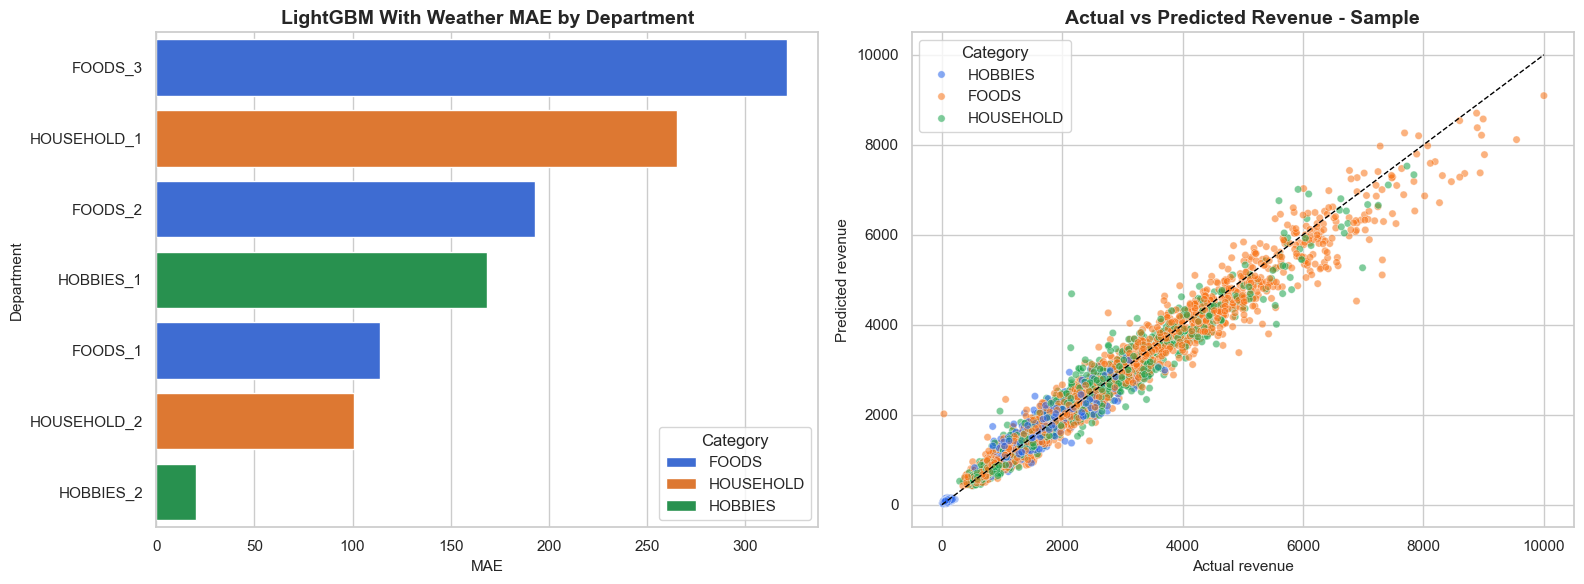

In [33]:
test_pred = test_df[["date", "store_id", "state_id", "cat_id", "dept_id", "store_dept_id", "daily_revenue"]].copy()
test_pred["pred_daily_revenue"] = primary_pred
test_pred["error"] = test_pred["pred_daily_revenue"] - test_pred["daily_revenue"]
test_pred["abs_error"] = test_pred["error"].abs()

error_by_dept = (
    test_pred.groupby(["cat_id", "dept_id"])
    .agg(
        n=("daily_revenue", "size"),
        actual_revenue=("daily_revenue", "sum"),
        predicted_revenue=("pred_daily_revenue", "sum"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
        mean_actual=("daily_revenue", "mean"),
    )
    .reset_index()
)
error_by_dept["wape"] = (error_by_dept["predicted_revenue"] - error_by_dept["actual_revenue"]).abs() / (error_by_dept["actual_revenue"] + 1e-12)
error_by_dept = error_by_dept.sort_values("mae", ascending=False)

display(error_by_dept.round({"actual_revenue": 2, "predicted_revenue": 2, "mae": 2, "bias": 2, "mean_actual": 2, "wape": 4}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=error_by_dept, y="dept_id", x="mae", hue="cat_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("LightGBM With Weather MAE by Department")
axes[0].set_xlabel("MAE")
axes[0].set_ylabel("Department")
axes[0].legend(title="Category")

sample_plot = test_pred.sample(min(5000, len(test_pred)), random_state=42)
sns.scatterplot(data=sample_plot, x="daily_revenue", y="pred_daily_revenue", hue="cat_id", alpha=0.55, s=28, palette=PALETTE_CONTRAST, ax=axes[1])
max_val = max(sample_plot["daily_revenue"].max(), sample_plot["pred_daily_revenue"].max())
axes[1].plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1)
axes[1].set_title("Actual vs Predicted Revenue - Sample")
axes[1].set_xlabel("Actual revenue")
axes[1].set_ylabel("Predicted revenue")
axes[1].legend(title="Category")

plt.tight_layout()
plt.show()


,store_id,state_id,n,actual_revenue,predicted_revenue,mae,bias,wape
8,WI_2,WI,1001,"2,174,041.9000","2,088,548.7300",224.4600,-85.4100,0.0393
2,CA_3,CA,1001,"2,914,702.2200","2,862,154.7200",211.0800,-52.5000,0.0180
1,CA_2,CA,1001,"2,036,471.6700","2,014,184.2200",210.2100,-22.2700,0.0109
6,TX_3,TX,1001,"1,877,768.3000","1,849,186.9400",176.8300,-28.5500,0.0152
5,TX_2,TX,1001,"1,860,137.7600","1,844,730.7000",163.1700,-15.3900,0.0083
0,CA_1,CA,1001,"2,067,578.2600","2,050,776.3000",160.3800,-16.7900,0.0081
7,WI_1,WI,1001,"1,646,180.9300","1,641,418.3300",158.4700,-4.7600,0.0029
9,WI_3,WI,1001,"1,581,725.1700","1,557,821.9600",146.2600,-23.8800,0.0151
4,TX_1,TX,1001,"1,467,844.7000","1,457,810.0900",136.7100,-10.0200,0.0068
3,CA_4,CA,1001,"1,208,815.1000","1,192,747.0400",103.4500,-16.0500,0.0133


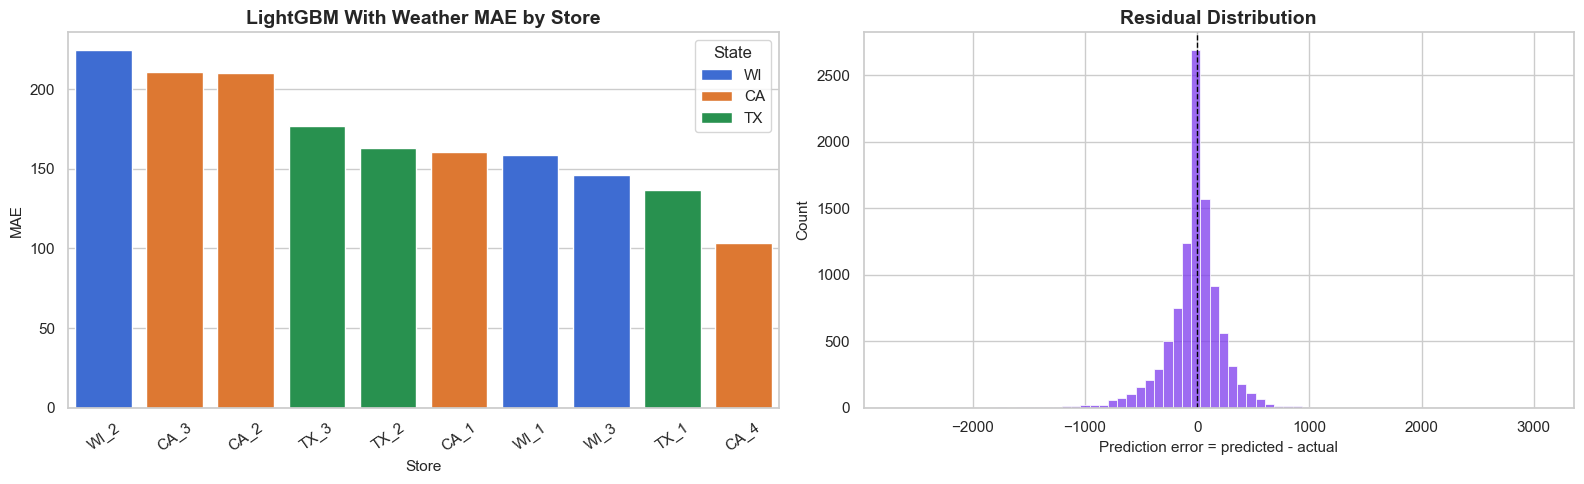

In [34]:
error_by_store = (
    test_pred.groupby(["store_id", "state_id"])
    .agg(
        n=("daily_revenue", "size"),
        actual_revenue=("daily_revenue", "sum"),
        predicted_revenue=("pred_daily_revenue", "sum"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
    )
    .reset_index()
)
error_by_store["wape"] = (error_by_store["predicted_revenue"] - error_by_store["actual_revenue"]).abs() / (error_by_store["actual_revenue"] + 1e-12)
error_by_store = error_by_store.sort_values("mae", ascending=False)

display(error_by_store.round({"actual_revenue": 2, "predicted_revenue": 2, "mae": 2, "bias": 2, "wape": 4}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=error_by_store, x="store_id", y="mae", hue="state_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("LightGBM With Weather MAE by Store")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="State")

sns.histplot(test_pred["error"], bins=70, color=COLOR_PURPLE, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Prediction error = predicted - actual")

plt.tight_layout()
plt.show()


**Error insight**

Sai số tuyệt đối cao hơn ở department có scale lớn là điều bình thường. Vì vậy cần đọc MAE cùng WAPE/bias: MAE cho biết quy mô lỗi tiền tệ, còn WAPE/bias cho biết LightGBM có lệch hệ thống ở store hoặc department nào không.

## 19. LightGBM Feature Importance

,feature,importance
10,num__doy_cos,2317
14,num__revenue_lag_1,2284
9,num__doy_sin,2202
17,num__revenue_lag_28,2176
3,num__date_index,1872
15,num__revenue_lag_7,1851
19,num__revenue_roll_mean_7,1627
7,num__dow_sin,1588
36,num__shortwave_radiation_mj_m2,1500
16,num__revenue_lag_14,1475


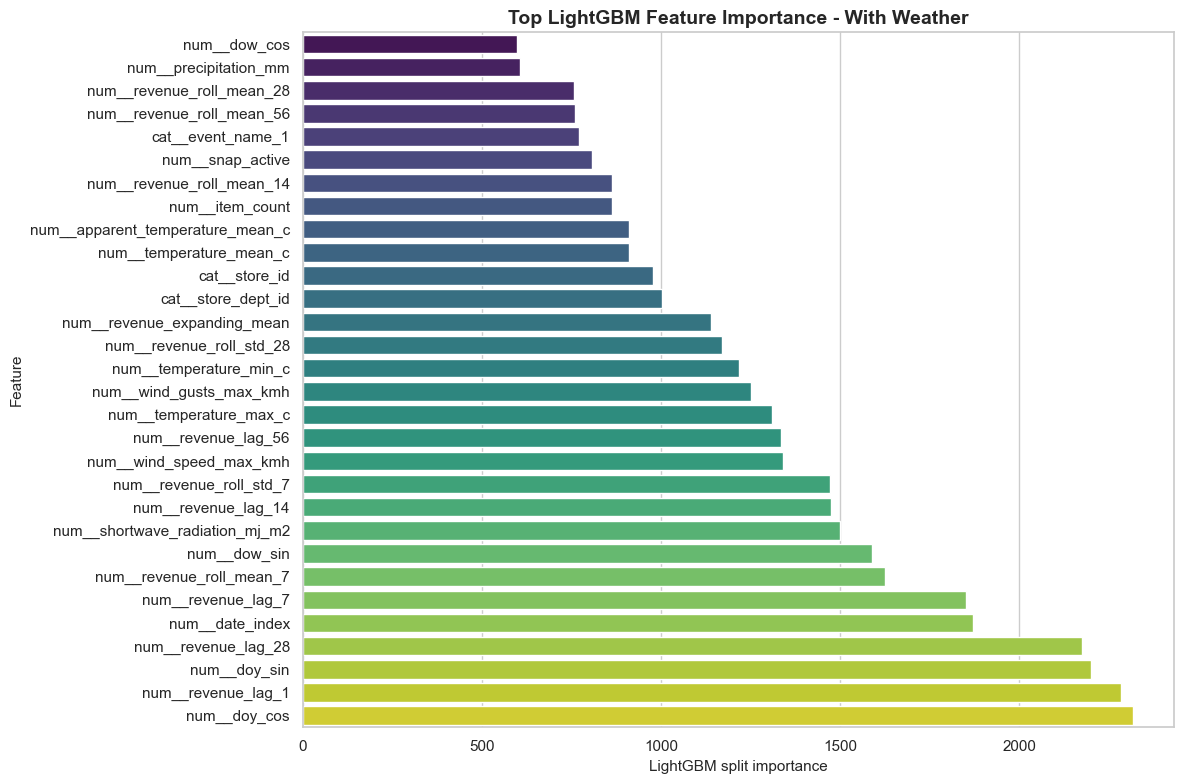

In [35]:
def get_transformed_feature_names(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        names = []
        for name, transformer, cols in preprocessor.transformers_:
            if name == "remainder" or transformer == "drop":
                continue
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    names.extend(transformer.get_feature_names_out(cols))
                except Exception:
                    names.extend(cols)
            else:
                names.extend(cols)
        return np.array(names)


def lightgbm_importance_table(model, top_n=30):
    estimator = model.named_steps["model"]
    feature_names = get_transformed_feature_names(model)
    values = estimator.feature_importances_

    n = min(len(feature_names), len(values))
    out = pd.DataFrame({
        "feature": feature_names[:n],
        "importance": values[:n],
    })
    return out.sort_values("importance", ascending=False).head(top_n)

importance_df = lightgbm_importance_table(primary_model, top_n=30)
display(importance_df)

plt.figure(figsize=(12, 8))
plot_df = importance_df.sort_values("importance")
sns.barplot(data=plot_df, x="importance", y="feature", palette="viridis")
plt.title("Top LightGBM Feature Importance - With Weather")
plt.xlabel("LightGBM split importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Interpretation caution**

LightGBM feature importance không phải causal effect. Nó cho biết biến nào hữu ích trong quá trình split của cây. Nếu các feature như lag/rolling, `store_dept_id`, calendar, SNAP/event và weather xuất hiện cao, điều đó xác nhận model đang dựa vào các signal hợp lý đã tìm thấy từ EDA.

## 20. Practical Forecasting Notes

In [36]:
# Final fit on all available data for future scoring, always using with-weather feature set.
final_lightgbm_all = build_lightgbm_with_weather_pipeline()
final_lightgbm_all.fit(df_model[feature_cols], df_model["daily_revenue"])

print("Final all-data model: LightGBM with weather")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Demo: score the last 7 days in the dataset as if they were future rows already prepared with lag features.
demo_rows = df_model[df_model["date"] >= df_model["date"].max() - pd.Timedelta(days=6)].copy()
demo_rows["pred_daily_revenue"] = np.clip(final_lightgbm_all.predict(demo_rows[feature_cols]), 0, None)

display(
    demo_rows[["date", "store_id", "dept_id", "daily_revenue", "pred_daily_revenue"]]
    .sample(12, random_state=7)
    .sort_values(["date", "store_id", "dept_id"])
    .round(2)
)


Final all-data model: LightGBM with weather
Numeric features: 42
Categorical features: 12


,date,store_id,dept_id,daily_revenue,pred_daily_revenue
73751,2016-05-16,TX_2,FOODS_3,"5,168.2000","4,650.8100"
130040,2016-05-16,WI_3,HOBBIES_1,765.8300,864.7800
133922,2016-05-16,WI_3,HOUSEHOLD_1,"2,079.7100","2,303.8600"
15523,2016-05-18,CA_2,FOODS_1,"1,243.4500","1,165.3400"
19405,2016-05-18,CA_2,FOODS_3,"4,460.4800","4,393.9700"
67930,2016-05-18,TX_1,HOUSEHOLD_2,971.4400,851.8600
95104,2016-05-18,TX_3,HOUSEHOLD_2,626.9500,782.4700
112574,2016-05-19,WI_2,FOODS_2,"2,685.0000","2,878.1300"
17466,2016-05-20,CA_2,FOODS_2,"1,721.0000","1,752.1500"
54345,2016-05-20,CA_4,HOUSEHOLD_2,786.5700,716.9700


**Forecasting note**

Để dự báo ngày tương lai thật với bản `with_weather`, cần tạo dataframe future có cùng schema feature:

- Calendar/event/SNAP biết trước.
- `store_dept_id` tạo trực tiếp từ `store_id` và `dept_id`.
- History features lấy từ dữ liệu trước ngày dự báo, không dùng doanh thu cùng ngày.
- Weather forecast tương lai là bắt buộc vì model đang dùng các biến thời tiết.

# 21. Kết Luận Tổng Hợp

Sau khi chỉnh lại, phần modeling của M5 chỉ sử dụng **LightGBM with weather** để train và đánh giá.

Kết luận chính:

1. Bài toán dự báo là `store_id × dept_id × date`, target là `daily_revenue`.
2. Model duy nhất: `LGBMRegressor` với objective `regression_l1`.
3. Feature set duy nhất: `with_weather`.
4. `store_dept_id` được thêm vào như interaction hợp lệ giữa store và department.
5. Model được validation trên năm 2015, sau đó train lại trên 2011-2015 và test cuối trên 2016.
6. Driver quan trọng nhất vẫn là lịch sử doanh thu, seasonality, baseline `store × dept`, SNAP/event, trend và weather conditions.